In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns


In [4]:
bu = pd.read_excel('bilans_uspjeha.xlsx')
bs = pd.read_excel('bilans_stanja.xlsx')
nt = pd.read_excel('izvjestaj_o_novcanim tokovima.xlsx')

In [5]:
bs.head(69)


,Pozicija,2021,2022,2023
0,NaN,NaN,NaN,NaN
1,A STALNA SREDSTVA (002+008+015+016+017+022+034),4972434,4770235,4058717.0
2,I NEMATERIJALNA SREDSTVA (003 do 007),NaN,NaN,NaN
3,Ulaganja u razvoj,NaN,NaN,NaN
4,"Koncesije, patenti, licence, softver i ostala...",NaN,NaN,NaN
...,...,...,...,...
64,Porez na dodatu vrijednost,453321,29998,72146.0
65,Kratkoročna razgraničenja,NaN,NaN,NaN
66,G BILANSNA AKTIVA (001 + 035 + 036),13783706,15527441,16798656.0
67,D VANBILANSNA AKTIVA,NaN,NaN,NaN


In [7]:
print(bs[bs['Pozicija'].str.contains('DUGOROČNE', na=False)])
print(bs[bs['Pozicija'].str.contains('OBAVEZE', na=False)])



                                              Pozicija 2021 2022  2023
99   B DUGOROČNA REZERVISANJA I DUGOROČNE OBAVEZE (...  NaN  NaN   NaN
104                  II DUGOROČNE OBAVEZE (138 do 144)  NaN  NaN   NaN
                                              Pozicija     2021    2022  \
99   B DUGOROČNA REZERVISANJA I DUGOROČNE OBAVEZE (...      NaN     NaN   
104                  II DUGOROČNE OBAVEZE (138 do 144)      NaN     NaN   
113                         V ODLOŽENE PORESKE OBAVEZE      NaN     NaN   
114  G KRATKOROČNE OBAVEZE I KRATKOROČNA REZERVISAN...  1223620  893057   

          2023  
99         NaN  
104        NaN  
113        NaN  
114  1226400.0  


# FINANSIJSKA RAVNOTEŽA

In [8]:
Kratkorocna_potrazivanja = bs.loc[45, [2021, 2022, 2023]]
Kratkoročni_finansijski_plasmani = bs.loc [52, [2021, 2022, 2023]].fillna(0)
Gotovina_i_gotovinski_ekvivalenti = bs.loc [61, [2021, 2022, 2023]]
Porez_na_dodatu_vrijednost = bs.loc [64, [2021, 2022, 2023]]
Aktivna_kratkoročna_razgraničenja = bs.loc [65, [2021, 2022, 2023]].fillna(0)
kratkoročne_obaveze = bs.loc[114, [2021 ,2022, 2023]]
KRATKOROČNA_VEZANA_SREDSTVA = Kratkorocna_potrazivanja + Kratkoročni_finansijski_plasmani + \
                              Gotovina_i_gotovinski_ekvivalenti + Porez_na_dodatu_vrijednost + \
                               Aktivna_kratkoročna_razgraničenja

KRATKOROČNA_FINANSIJSKA_RAVNOTEŽA = KRATKOROČNA_VEZANA_SREDSTVA / kratkoročne_obaveze

KRATKOROČNA_VEZANA_SREDSTVA_df = pd.DataFrame({
    'Kratkorocna potrazivanja': Kratkorocna_potrazivanja,
    'Kratkoročni finansijski plasmani': Kratkoročni_finansijski_plasmani,
    'Gotovina i gotovinski ekvivalenti': Gotovina_i_gotovinski_ekvivalenti,
    'Porez na dodatu vrijednost': Porez_na_dodatu_vrijednost,
    'Aktivna kratkoročna razgraničenja': Aktivna_kratkoročna_razgraničenja,
    'I Kratkoročna vezana sredstva': KRATKOROČNA_VEZANA_SREDSTVA,
    'II Kratkoročni izvori finansiranja' : kratkoročne_obaveze,
    'KRATKOROČNA FINANSIJSKA RAVNOTEŽA (I/II)': KRATKOROČNA_FINANSIJSKA_RAVNOTEŽA
}).T

KRATKOROČNA_VEZANA_SREDSTVA_df


C:\Users\User\AppData\Local\Temp\ipykernel_15188\1774203336.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Kratkoročni_finansijski_plasmani = bs.loc [52, [2021, 2022, 2023]].fillna(0)
C:\Users\User\AppData\Local\Temp\ipykernel_15188\1774203336.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Aktivna_kratkoročna_razgraničenja = bs.loc [65, [2021, 2022, 2023]].fillna(0)


,2021,2022,2023
Kratkorocna potrazivanja,1155261,1446326,4682513.0
Kratkoročni finansijski plasmani,0,0,0
Gotovina i gotovinski ekvivalenti,6776425,8926899,7631301.0
Porez na dodatu vrijednost,453321,29998,72146.0
Aktivna kratkoročna razgraničenja,0,0,0
I Kratkoročna vezana sredstva,8385007,10403223,12385960.0
II Kratkoročni izvori finansiranja,1223620,893057,1226400.0
KRATKOROČNA FINANSIJSKA RAVNOTEŽA (I/II),6.852623,11.649002,10.099446


Text(0.5, 1.0, 'Grafikon za Kratkoročnu Finansijsku Ravnotežu')

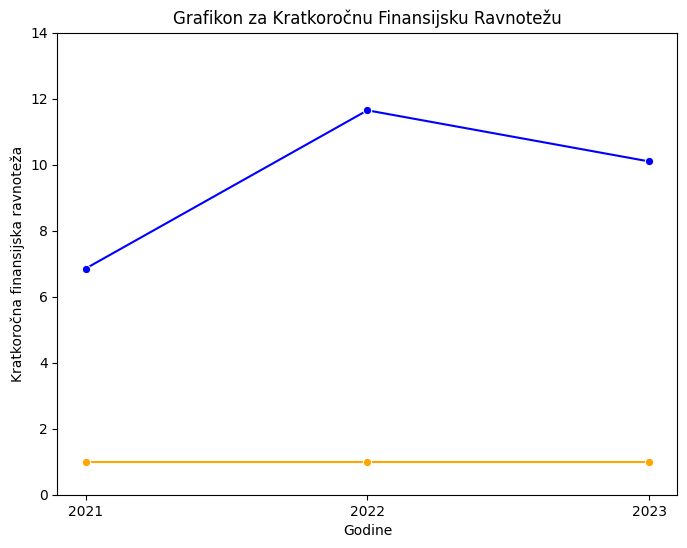

In [9]:
years = [2021, 2022, 2023]
referentna_vrijednost = [1, 1, 1]

# Vrijednosti KRATKOROČNA FINANSIJSKA RAVNOTEŽA (I/II) za 2021, 2022, 2023
values = [6.852623, 11.649002, 10.099446]

# Kreiranje grafika
plt.figure(figsize=(8, 6))
sns.lineplot(x=years, y=values, marker='o', color='b')
sns.lineplot(x=years, y=referentna_vrijednost, marker='o', color='orange')

# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(range(0, 16, 2))  # Prikaz vrijednosti na y-osi od 1 do 15, sa razmakom od 2

# Oznake
plt.xlabel('Godine')
plt.ylabel('Kratkoročna finansijska ravnoteža' )
plt.title('Grafikon za Kratkoročnu Finansijsku Ravnotežu')

In [14]:
Stalna_imovina = bs.loc[1, [2021, 2022, 2023]]
Zalihe_stalna_sredstva = bs.loc[37, [2021, 2022, 2023]]
DUGOROČNA_VEZANA_IMOVINA = Stalna_imovina + Zalihe_stalna_sredstva

Kapital = bs.loc[68, [2021, 2022, 2023]]
Rezervisanja_i_odloženiPoreskiPrihodi = (bs.loc[100, [2021, 2022, 2023]].fillna(0) + bs.loc[112, [2021, 2022, 2023]].fillna(0) + bs.loc[113, [2021, 2022, 2023]].fillna(0)).infer_objects(copy=False)
dugoročne_obaveze = bs. loc[104, [2021, 2022, 2023]].fillna(0)
TRAJNI_I_DUGOROČNI_KAPITAL = Kapital + Rezervisanja_i_odloženiPoreskiPrihodi + dugoročne_obaveze

DUGOROČNA_VEZANA_IMOVINA = DUGOROČNA_VEZANA_IMOVINA.squeeze()
DUGOROČNA_FINANSIJSKA_RAVNOTEŽA = DUGOROČNA_FINANSIJSKA_RAVNOTEŽA.squeeze()

# Kreiranje DataFrame-a
DUGOROČNA_VEZANA_IMOVINA_df = pd.DataFrame({
    'Stalna imovina': Stalna_imovina,
    'Zalihe stalnih sredstava': Zalihe_stalna_sredstva,
    'I DUGOROČNA VEZANA IMOVINA': DUGOROČNA_VEZANA_IMOVINA,
    'Kapital': Kapital,
    'Rezervisanja i odloženi poreski prihodi': Rezervisanja_i_odloženiPoreskiPrihodi,
    'Dugoročne obaveze': dugoročne_obaveze,
    'II TRAJNI I DUGOROČNI KAPITAL': TRAJNI_I_DUGOROČNI_KAPITAL,
    'DUGOROČNA FINANSIJSKA RAVNOTEŽA (I/II)': DUGOROČNA_FINANSIJSKA_RAVNOTEŽA
}).T

DUGOROČNA_VEZANA_IMOVINA_df


C:\Users\User\AppData\Local\Temp\ipykernel_15188\1195394491.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Rezervisanja_i_odloženiPoreskiPrihodi = (bs.loc[100, [2021, 2022, 2023]].fillna(0) + bs.loc[112, [2021, 2022, 2023]].fillna(0) + bs.loc[113, [2021, 2022, 2023]].fillna(0)).infer_objects(copy=False)
C:\Users\User\AppData\Local\Temp\ipykernel_15188\1195394491.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Rezervisanja_i_odloženiPoreskiPrihodi = (bs.loc[100, [2021, 2022, 2023]].fillna(0) + bs.loc[112, [2021, 2022, 2023]].fillna(0) + bs.loc[11

,2021,2022,2023
Stalna imovina,4972434,4770235,4058717.0
Zalihe stalnih sredstava,426265,84001,353979.0
I DUGOROČNA VEZANA IMOVINA,5398699,4854236,4412696.0
Kapital,12560086,14634384,15572256.0
Rezervisanja i odloženi poreski prihodi,0,0,0
Dugoročne obaveze,0,0,0
II TRAJNI I DUGOROČNI KAPITAL,12560086,14634384,15572256.0
DUGOROČNA FINANSIJSKA RAVNOTEŽA (I/II),0.42983,0.331701,0.283369


Text(0.5, 1.0, 'Grafikon za Dugoročnu Finansijsku Ravnotežu')

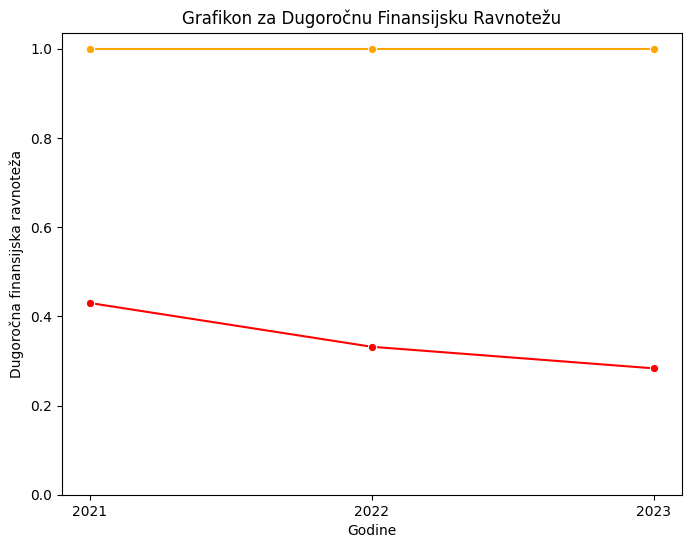

In [15]:
years = [2021, 2022, 2023]
referentna_vrijednost = [1, 1, 1]
# Vrijednosti KRATKOROČNA FINANSIJSKA RAVNOTEŽA (I/II) za 2021, 2022, 2023
values = [0.42983, 0.331701, 0.283369]

# Kreiranje grafika
plt.figure(figsize=(8, 6))
sns.lineplot(x=years, y=values, marker='o', color='r')
sns.lineplot(x=years, y=referentna_vrijednost, marker='o', color='orange')
# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 1.1, 0.2))  # Prikaz vrijednosti na y-osi od 1 do 15, sa razmakom od 2

# Oznake
plt.xlabel('Godine')
plt.ylabel('Dugoročna finansijska ravnoteža' )
plt.title('Grafikon za Dugoročnu Finansijsku Ravnotežu')

In [16]:
TRAJNI_I_DUGOROČNI_KAPITAL_COPY
Stalna_imovina
NETO_OBRTNI_KAPITAL = TRAJNI_I_DUGOROČNI_KAPITAL_COPY - Stalna_imovina
Zalihe_stalna_sredstva
STOPA_POKRIVENOSTI_ZALIHA = (NETO_OBRTNI_KAPITAL / Zalihe_stalna_sredstva) * 100
STOPA_POKRIVENOSTI_ZALIHA = pd.DataFrame (STOPA_POKRIVENOSTI_ZALIHA)
STOPA_POKRIVENOSTI_ZALIHA.columns = ['Stopa pokrivenosti zaliha']
STOPA_POKRIVENOSTI_ZALIHA

,Stopa pokrivenosti zaliha
2021,1780.03167
2022,11742.894727
2023,3252.605098


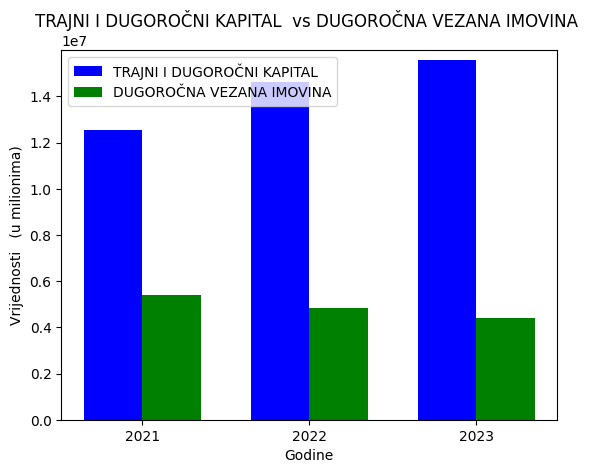

In [18]:
years = [2021, 2022, 2023]

# Vrijednosti za TRAJNI_I_DUGOROČNI_KAPITAL_COPY i DUGOROČNA_VEZANA_IMOVINA_COPY
TRAJNI_I_DUGOROČNI_KAPITAL_COPY = [12560086, 14634384, 15572256]
DUGOROČNA_VEZANA_IMOVINA_COPY = [5398699, 4854236, 4412696]

# Širina bara
bar_width = 0.35

# X-pozicije za TRAJNI_I_DUGOROČNI_KAPITAL_COPY
r1 = np.arange(len(years))


# X-pozicije za DUGOROČNA_VEZANA_IMOVINA_COPY (pomjerene za bar_width)
r2 = [x + bar_width for x in r1]

# Kreiranje bar grafika
plt.bar(r1, TRAJNI_I_DUGOROČNI_KAPITAL_COPY, color='b', width=bar_width, label='TRAJNI I DUGOROČNI KAPITAL' )
plt.bar(r2, DUGOROČNA_VEZANA_IMOVINA_COPY, color='g', width=bar_width, label='DUGOROČNA VEZANA IMOVINA')

# Dodavanje naziva za x-osu, y-osu i naslov
plt.xlabel('Godine')
plt.ylabel('Vrijednosti   (u milionima)')
plt.title('TRAJNI I DUGOROČNI KAPITAL  vs DUGOROČNA VEZANA IMOVINA ')

# Postavljanje oznaka za x-osu
plt.xticks([r + bar_width / 2 for r in r1], years)

plt.ylim(0, 16000000)  # Maksimalna vrijednost na y-osi
plt.yticks(np.arange(0, 16000000, 2000000))  # Korak od 2.000.000

# Prikazivanje legende
plt.legend()

# Prikazivanje grafika
plt.show()

## POKAZATELJI LIKVIDNOSTI

In [19]:
obrtna_sredstva = bs.loc[36, [2021 ,2022, 2023]]
kratkoročne_obaveze = bs.loc[114, [2021 ,2022, 2023]]
Tekuća_likvidnost = obrtna_sredstva / kratkoročne_obaveze

KTL = pd.DataFrame ({
    'Obrtna sredstva' : obrtna_sredstva,
    'Kratkoročne obaveze' : kratkoročne_obaveze,
    'Tekuća likvidnost' : Tekuća_likvidnost
}).T

KTL

,2021,2022,2023
Obrtna sredstva,8811272,10757206,12739939.0
Kratkoročne obaveze,1223620,893057,1226400.0
Tekuća likvidnost,7.200987,12.045374,10.388078


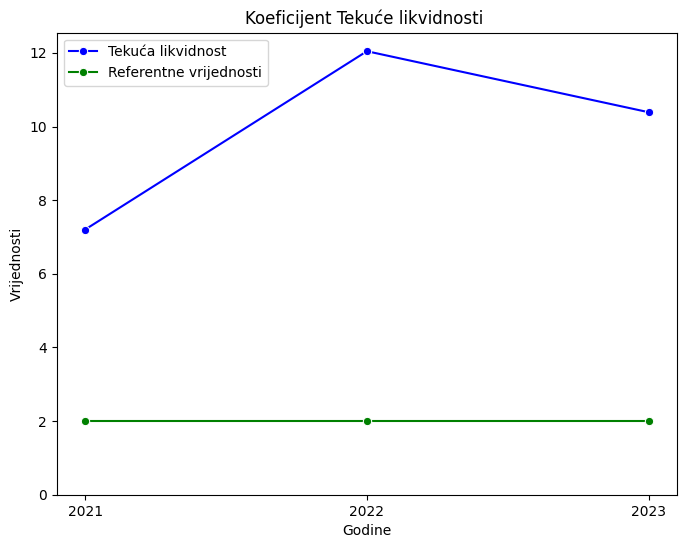

In [20]:
years = [2021, 2022, 2023]
tekuća_likvidnost = [7.200987, 12.045374, 10.388078]
referentne_vrijednosti = [2, 2, 2]
plt.figure(figsize=(8, 6))
sns.lineplot(x=years, y=tekuća_likvidnost, marker='o', color='b', label='Tekuća likvidnost')
sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(range(0, 13, 2))   # Postavljanje y-osi do 13
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent Tekuće likvidnosti ')
plt.legend()

plt.show()

In [21]:
Gotovina = bs.loc[63, [2021 ,2022, 2023]]
kratkoročna_potraživanja = bs.loc[45, [2021 ,2022, 2023]]
kratkoročne_obaveze = bs.loc[114, [2021 ,2022, 2023]]
Redukovana_likvidnost= (Gotovina + kratkoročna_potraživanja) / \
                        kratkoročne_obaveze
KRL = pd.DataFrame ({
    'Gotovina' : Gotovina,
    'Kratkoročna potraživanja' : kratkoročna_potraživanja,
    'Kratkoročne obaveze' : kratkoročne_obaveze,
    'Redukovana likvidnost' : Redukovana_likvidnost
}).T

KRL

,2021,2022,2023
Gotovina,6776425,8926899,7631301.0
Kratkoročna potraživanja,1155261,1446326,4682513.0
Kratkoročne obaveze,1223620,893057,1226400.0
Redukovana likvidnost,6.482148,11.615412,10.040618


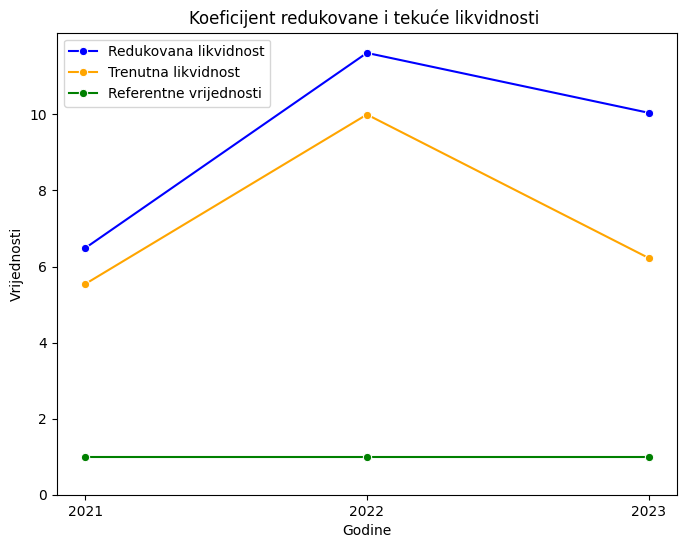

In [22]:
years = [2021, 2022, 2023]
redukovana_likvidnost = [6.482148, 11.615412, 10.040618 ]
trenutna_likvidnost = [5.538014, 9.995889, 6.222522 ]
referentne_vrijednosti = [1, 1, 1]

plt.figure(figsize=(8, 6))

sns.lineplot(x=years, y=redukovana_likvidnost, marker='o', color='b', label='Redukovana likvidnost')
sns.lineplot(x=years, y=trenutna_likvidnost, marker='o', color='orange', label='Trenutna likvidnost')
sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(range(0, 12, 2))   # Postavljanje y-osi do 13

plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent redukovane i tekuće likvidnosti ')
plt.legend()

plt.show()

In [23]:
Gotovina = bs.loc[63, [2021 ,2022, 2023]]
kratkoročne_obaveze = bs.loc[114, [2021 ,2022, 2023]]
Trenutna_likvidnost = Gotovina / kratkoročne_obaveze

KTrL = pd.DataFrame ({
    'Gotovina' : Gotovina,
    'Kratkoročne obaveze' : kratkoročne_obaveze,
    'Trenutna likvidnost':Trenutna_likvidnost
}).T
KTrL

,2021,2022,2023
Gotovina,6776425,8926899,7631301.0
Kratkoročne obaveze,1223620,893057,1226400.0
Trenutna likvidnost,5.538014,9.995889,6.222522


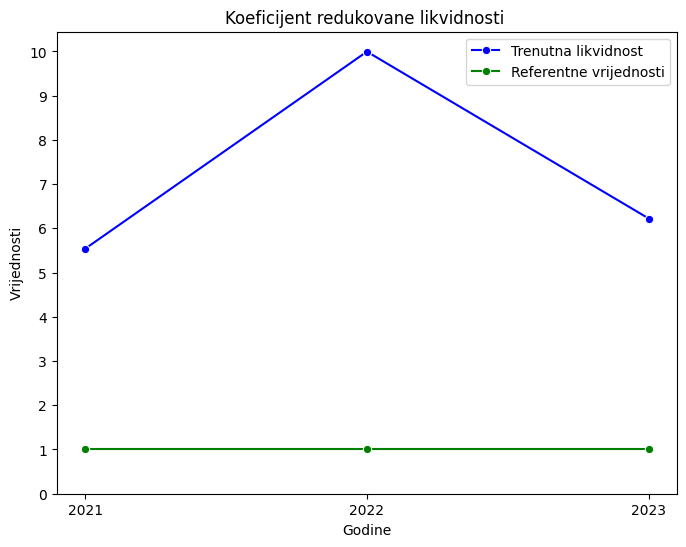

In [24]:
years = [2021, 2022, 2023]

# Vrijednosti za tekuću likvidnost
trenutna_likvidnost = [5.538014, 9.995889, 6.222522 ]

# Referentne vrijednosti
referentne_vrijednosti = [1, 1, 1]

# Kreiranje grafika
plt.figure(figsize=(8, 6))

# Linija za tekuću likvidnost
sns.lineplot(x=years, y=trenutna_likvidnost, marker='o', color='b', label='Trenutna likvidnost')

# Linija za referentne vrijednosti
sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')

# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(range(0, 11, 1))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent redukovane likvidnosti ')

# Prikaz legende
plt.legend()

# Prikaz grafika
plt.show()

In [25]:
prihodi_od_prodaje =bu.loc[3, [2021 ,2022, 2023]]
Likvidnost_potraživanja = (kratkoročna_potraživanja * 365) / prihodi_od_prodaje
Likvidnost_potraživanja

2021     57.474465
2022    100.057541
2023    391.617362
dtype: object

# SOLVENTNOST I ZADUŽENOST


In [26]:
poslovna_imovina = bs.loc[66, [2021 ,2022, 2023]]
dugovi = bs.loc[114, [2021, 2022, 2023]]
solventnost = poslovna_imovina / dugovi
solventnost

2021    11.264695
2022    17.386842
2023    13.697534
dtype: object

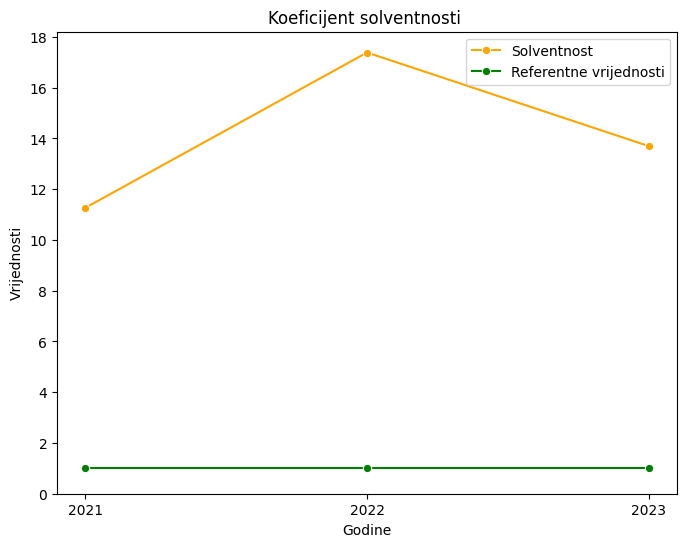

In [27]:
years = [2021, 2022, 2023]

# Vrijednosti za tekuću likvidnost
solventnost = [11.264695, 17.386842, 13.697534]

# Referentne vrijednosti
referentne_vrijednosti = [1, 1, 1]

# Kreiranje grafika
plt.figure(figsize=(8, 6))

# Linija za tekuću likvidnost
sns.lineplot(x=years, y=solventnost, marker='o', color='orange', label='Solventnost')

# Linija za referentne vrijednosti
sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')

# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(range(0, 20, 2))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent solventnosti ')

# Prikaz legende
plt.legend()

# Prikaz grafika
plt.show()

In [52]:
Kapital=bs.loc[68, [2021 ,2022, 2023]]
dugovi = bs.loc[114, [2021, 2022, 2023]]
Pasiva=Kapital + dugovi
Stepen_zaduženost = dugovi / Pasiva * 100
Stepen_zaduženost

Zaduzenost = pd.DataFrame({
    'Kapital' : Kapital,
    'dugovi' : dugovi,
    'Pasiva' : Pasiva,
    'Stepen zaduženosti' : Stepen_zaduženost
}).T

Zaduzenost


,2021,2022,2023
Kapital,12560086,14634384,15572256.0
dugovi,1223620,893057,1226400.0
Pasiva,13783706,15527441,16798656.0
Stepen zaduženosti,8.877293,5.751476,7.300584


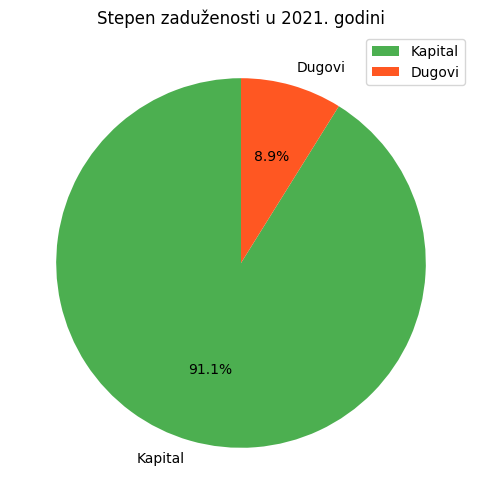

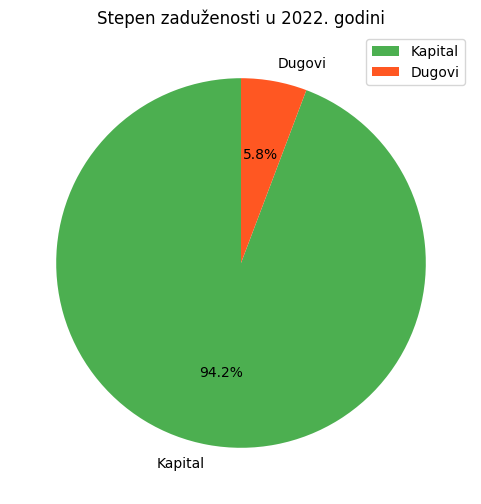

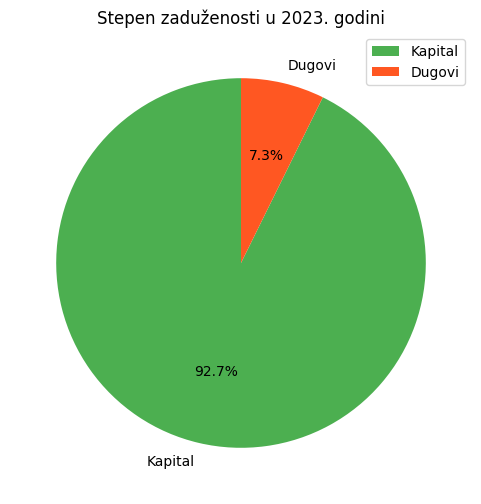

In [29]:
kapital = bs.loc[68, [2021, 2022, 2023]]
dugovi = bs.loc[114, [2021, 2022, 2023]]

# Funkcija za crtanje pie grafikona
def plot_pie(godina, kapital, dugovi):
    plt.figure(figsize=(6, 6))  # Veličina grafika
    plt.pie([kapital, dugovi], labels=['Kapital', 'Dugovi'], autopct='%1.1f%%', 
            colors=['#4CAF50', '#FF5722'], startangle=90)
    plt.title(f'Stepen zaduženosti u {godina}. godini')
    plt.legend()
    plt.show()

# Poziv funkcije za svaku godinu
for godina in [2021, 2022, 2023]:
    plot_pie(godina, kapital[godina], dugovi[godina])

# ADEKVATNOST KAPITALA

In [109]:
Osnovni_kapital=bs.loc[69, [2021 ,2022, 2023]]
Rezerve=bs.loc[82, [2021 ,2022, 2023]] 
Neraspoređena_dobit=bs.loc[91, [2021 ,2022, 2023]]
Emisiona_premija = bs.loc[80, [2021,2022, 2023]].fillna(0).sum()
NašKapital=Osnovni_kapital+Rezerve+Neraspoređena_dobit+Emisiona_premija
print(NašKapital)

a =Osnovni_kapital/NašKapital*100
b= Rezerve/NašKapital*100
c=Neraspoređena_dobit/NašKapital*100


d = pd.DataFrame ({
    'Osnovni kapital u Kapitalu' : a.round(2),
    'Rezerve u Kapitalu' : b.round(2),
    'Neraspoređena dobit u Kapitalu' : c.round(2)
    
}).T

d

2021        12560086
2022        14634384
2023   15,572,256.00
dtype: object


C:\Users\User\AppData\Local\Temp\ipykernel_15188\4023823911.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Emisiona_premija = bs.loc[80, [2021,2022, 2023]].fillna(0).sum()


,2021,2022,2023
Osnovni kapital u Kapitalu,22.73,19.51,18.34
Rezerve u Kapitalu,5.46,4.69,4.41
Neraspoređena dobit u Kapitalu,71.80,75.80,77.26


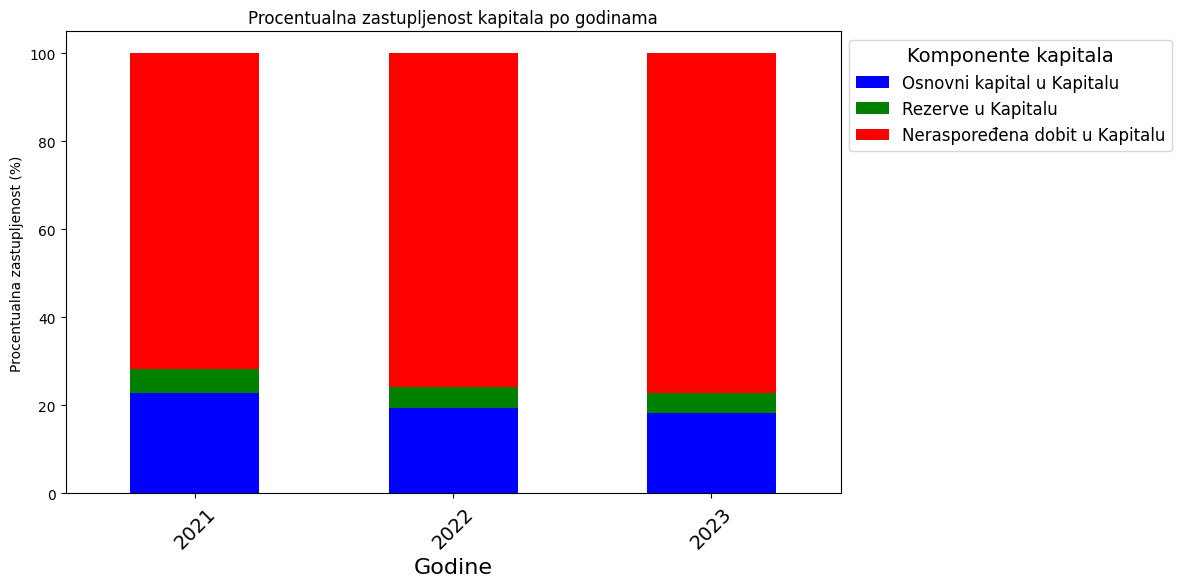

In [110]:
d = pd.DataFrame({
    'Osnovni kapital u Kapitalu': [22.73326, 19.511016, 18.335924],
    'Rezerve u Kapitalu': [5.463721, 4.689285, 4.406863],
    'Neraspoređena dobit u Kapitalu': [71.80302, 75.799699, 77.257213]
}, index=[2021, 2022, 2023])

# Kreiranje stacked bar grafikona
d.plot(kind='bar', stacked=True, figsize=(10, 6), color=['blue', 'green', 'red'])

# Dodavanje oznaka i naslova
plt.xlabel('Godine', fontsize = 16)
plt.xticks (rotation = 45, fontsize = 14)
plt.ylabel('Procentualna zastupljenost (%)')
plt.title('Procentualna zastupljenost kapitala po godinama')
plt.legend(title='Komponente kapitala', bbox_to_anchor=(1, 1), loc='upper left', fontsize=12, title_fontsize=14)

# Prikaz grafikona
plt.show()

# STANJE I EFIKASNOST IMOVINE

In [107]:
pd.set_option('display.float_format', '{:,.2f}'.format)
Ukupni_prihodi=bu.loc[78, [2021 ,2022, 2023]]
prosječna_aktiva_2023 = (bs.loc[66, 2023] + bs.loc[66, 2022]) / 2
prosječna_aktiva_2022 = (bs.loc[66, 2022] + bs.loc[66, 2021]) / 2
prosječna_aktiva_2021 = (bs.loc[66, 2021] + 13417831 )/ 2
prosječne_aktive = [prosječna_aktiva_2021, prosječna_aktiva_2022, prosječna_aktiva_2023]
prosječne_aktive_series = pd.Series(prosječne_aktive, index=[2021, 2022, 2023])
Ukupni_prihodi = pd.to_numeric(Ukupni_prihodi, errors='coerce')
Referetna_vrijednost = [0, 0, 0]



Efikasnost_imovine = Ukupni_prihodi / prosječne_aktive_series
Efikasnost_imovine.round(3)

EFI = pd.DataFrame ({
    'Ukupni prihodi' : Ukupni_prihodi,
    'Prosječna poslovna imovina' : prosječne_aktive_series,
    'Efikasnost imovine' :  Efikasnost_imovine.round(3),
   'REFERETNA VRIJEDNOST (Veća od ..)' :Referetna_vrijednost
}).T

EFI.loc['Efikasnost imovine'] = EFI.loc['Efikasnost imovine'].apply(lambda x: f"{x:,.3f}")
EFI.loc['REFERETNA VRIJEDNOST (Veća od ..)'] = EFI.loc['REFERETNA VRIJEDNOST (Veća od ..)'].apply(lambda x: f"{x:,.3f}")

EFI

C:\Users\User\AppData\Local\Temp\ipykernel_15188\3848991726.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.548' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  EFI.loc['Efikasnost imovine'] = EFI.loc['Efikasnost imovine'].apply(lambda x: f"{x:,.3f}")
C:\Users\User\AppData\Local\Temp\ipykernel_15188\3848991726.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.754' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  EFI.loc['Efikasnost imovine'] = EFI.loc['Efikasnost imovine'].apply(lambda x: f"{x:,.3f}")
C:\Users\User\AppData\Local\Temp\ipykernel_15188\3848991726.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.687' has dtype incompatible with

,2021,2022,2023
Ukupni prihodi,"7,451,511.00","11,045,905.00","11,108,564.00"
Prosječna poslovna imovina,"13,600,768.50","14,655,573.50","16,163,048.50"
Efikasnost imovine,0.548,0.754,0.687
REFERETNA VRIJEDNOST (Veća od ..),0.000,0.000,0.000


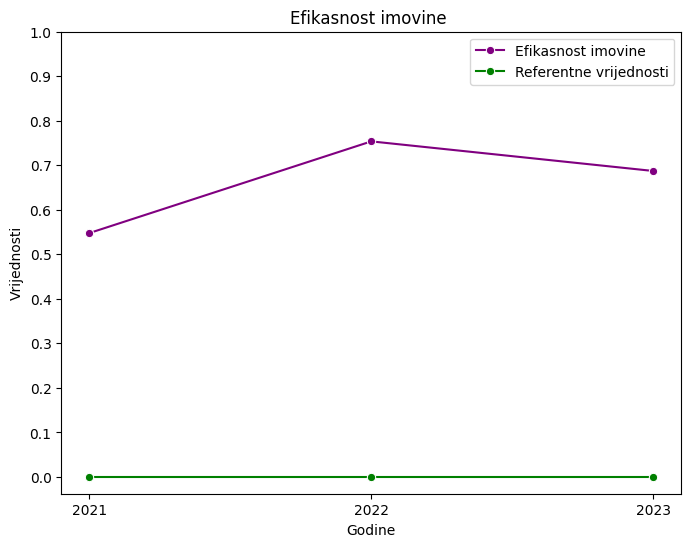

In [34]:
years = [2021, 2022, 2023]
efikasnost_imovine = [0.547874, 0.753700, 0.687281]
referentne_vrijednosti = [0, 0, 0]
plt.figure(figsize=(8, 6))

sns.lineplot(x=years, y=efikasnost_imovine, marker='o', color='purple', label='Efikasnost imovine')
sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')

plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 1.1, 0.1))   # Postavljanje y-osi do 13

plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Efikasnost imovine ')
plt.legend()

plt.show()

# KOEFICIJENT OBRTA ZALIHA


#### KOEFICIJENT OBRTNE IMOVINE I DANI VEZIVANJA OBRTNE IMOVINE

In [130]:
pd.reset_option('display.float_format')

KOI = pd.DataFrame({
    'Prihodi od prodaje': prihodi_od_prodaje.round(2),  # Zaokruženo na 2 decimale
    'Prosječna obrtna sredstva': prosječna_obrtna_sredstva_series.round(2),  # Zaokruženo na 2 decimale
    'Koeficijent obrtne imovine': Koeficijent_obrtne_imovine  # Zaokruženo na 3 decimale
}).T

KOI.iloc[0] = KOI.iloc[0].map('{:,.1f}'.format)
KOI.iloc[2] = KOI.iloc[2].map('{:,.3f}'.format)

KOI

,2021,2022,2023
Prihodi od prodaje,"7,336,654.0","5,276,054.0","4,364,253.0"
Prosječna obrtna sredstva,9085570.0,9784239.0,11748572.5
Koeficijent obrtne imovine,0.808,0.539,0.371


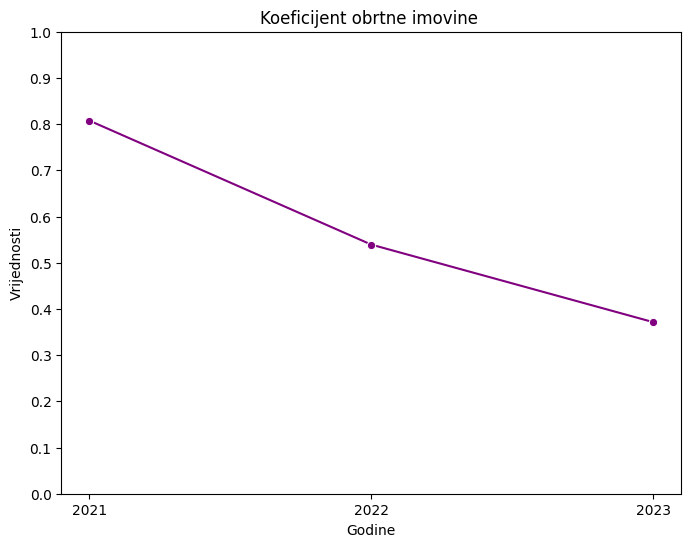

In [36]:
years = [2021, 2022, 2023]
koi = [0.807506, 0.53924, 0.371471]



# Kreiranje grafika
plt.figure(figsize=(8, 6))

# Linija za tekuću likvidnost
sns.lineplot(x=years, y=koi, marker='o', color='purple')


# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 1.1, 0.1))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent obrtne imovine ')


# Prikaz grafika
plt.show()

In [133]:
Dani_vezivanja_obrtne_imovine = 365 / Koeficijent_obrtne_imovine
Dani_vezivanja_obrtne_imovine = pd.DataFrame (Dani_vezivanja_obrtne_imovine)
Dani_vezivanja_obrtne_imovine.columns = ['Dani vezivanja obrtne imovine (365/Koeficijent_obrtne_imovine)' ]
Dani_vezivanja_obrtne_imovine

,Dani vezivanja obrtne imovine (365/Koeficijent_obrtne_imovine)
2021,452.00892
2022,676.878446
2023,982.580286


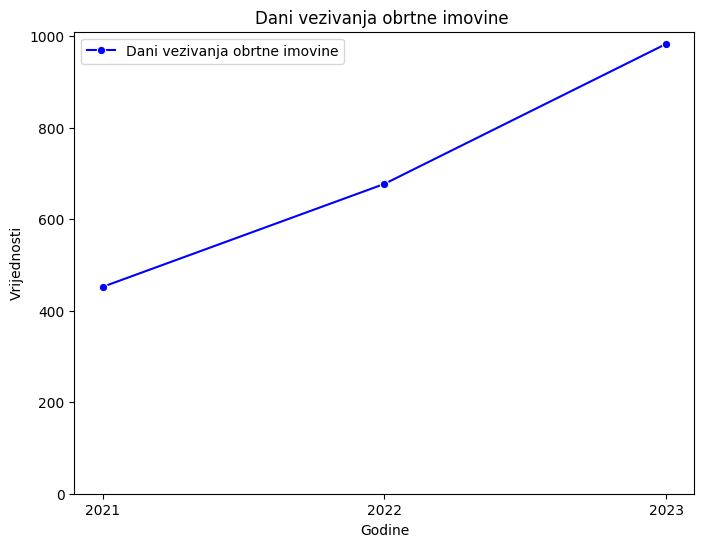

In [38]:
years = [2021, 2022, 2023]
dvoi = [452, 677, 983]

plt.figure(figsize=(8, 6))

sns.lineplot(x=years, y=dvoi, marker='o', color='blue', label='Dani vezivanja obrtne imovine')

plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 1100, 200))   # Postavljanje y-osi do 13

plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Dani vezivanja obrtne imovine ')

# Prikaz legende
plt.legend()

# Prikaz grafika
plt.show()

#### KOEFICIJENT I DANI VEZIVANJA ZALIHA

In [136]:
prihodi_od_prodaje =bu.loc[3, [2021 ,2022, 2023]]
prosječne_zalihe_2023 = (bs.loc[37,  2023] + bs.loc[38,  2022]) / 2
prosječne_zalihe_2022 = (bs.loc[37,  2022] + bs.loc[38,  2021]) / 2
prosječne_zalihe_2021 = (bs.loc[37,  2021] + 141743) / 2
prosječne_zalihe = (prosječne_zalihe_2021, prosječne_zalihe_2022, prosječne_zalihe_2023)
prosječne_zalihe_series=pd.Series(prosječne_zalihe, index=[2021, 2022, 2023])

Koeficijent_zaliha=prihodi_od_prodaje/prosječne_zalihe_series

KOZ = pd.DataFrame({
    'Prihodi od prodaje': prihodi_od_prodaje,  
    'Prosječne obrtne zalihe': prosječne_zalihe_series,
    'Koeficijent zaliha': Koeficijent_zaliha  # Zaokruženo na 3 decimale
}).T

KOZ.iloc[0] = KOZ.iloc[0].map('{:,.1f}'.format)
KOZ.iloc[2] = KOZ.iloc[2].map('{:,.3f}'.format)

KOZ

,2021,2022,2023
Prihodi od prodaje,"7,336,654.0","5,276,054.0","4,364,253.0"
Prosječne obrtne zalihe,284004.0,219988.5,218990.0
Koeficijent zaliha,25.833,23.983,19.929


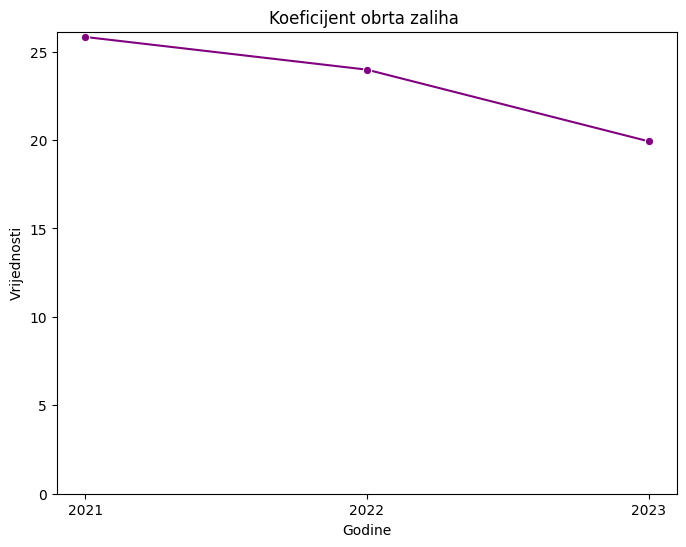

In [40]:
years = [2021, 2022, 2023]
koi = [25.832925, 23.983317, 19.929006]

# Kreiranje grafika
plt.figure(figsize=(8, 6))

sns.lineplot(x=years, y=koi, marker='o', color='purple')

# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 30, 5))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent obrta zaliha ')

# Prikaz grafika
plt.show()

In [137]:
dani_vezivanja_zaliha= 365 / Koeficijent_zaliha
dani_vezivanja_zaliha

dani_vezivanja_zaliha = pd.DataFrame (dani_vezivanja_zaliha)
dani_vezivanja_zaliha.columns = ['Dani vezivanja zaliha (365/Koeficijent zaliha)' ]
dani_vezivanja_zaliha

,Dani vezivanja zaliha (365/Koeficijent zaliha)
2021,14.129256
2022,15.218912
2023,18.315013


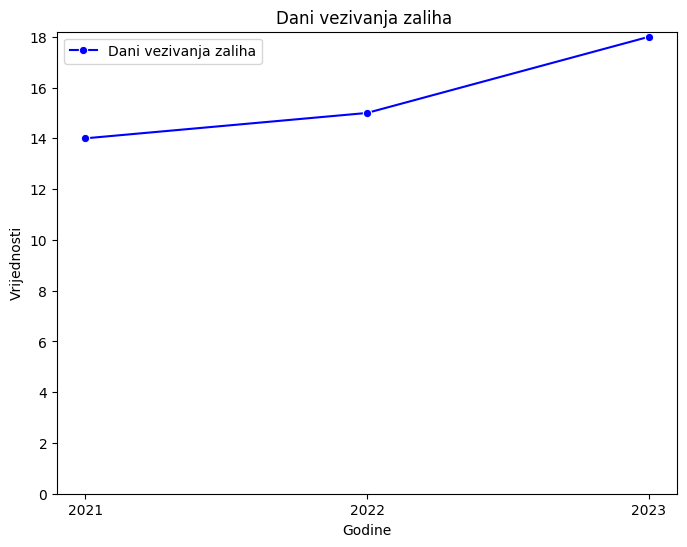

In [42]:
years = [2021, 2022, 2023]
dvoi = [14, 15, 18]


# Kreiranje grafika
plt.figure(figsize=(8, 6))

# Linija za tekuću likvidnost
sns.lineplot(x=years, y=dvoi, marker='o', color='blue', label='Dani vezivanja zaliha')


# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 20, 2))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Dani vezivanja zaliha ')

# Prikaz legende
plt.legend()

# Prikaz grafika
plt.show()

#### KOEFICIJENT OBRTA I DANI VEZIVANJA POTRAŽIVANJA

In [139]:
prihodi_od_prodaje =bu.loc[3, [2021 ,2022, 2023]]
prosječna_potraživanja_2023 = (bs.loc[45,  2023] + bs.loc[45,  2022]) / 2
prosječna_potraživanja_2022 = (bs.loc[45,  2022] + bs.loc[45,  2021]) / 2
prosječna_potraživanja_2021 = (bs.loc[45,  2021] + 1660537) / 2
prosječna_potraživanja = (prosječna_potraživanja_2021, prosječna_potraživanja_2022,
                          prosječna_potraživanja_2023)
prosječna_potraživanja_series=pd.Series(prosječna_potraživanja, index=[2021, 2022, 2023])

Koeficijent_potraživanja = prihodi_od_prodaje / prosječna_potraživanja_series

KOP = pd.DataFrame({
    'Prihodi od prodaje': prihodi_od_prodaje,  
    'Prosječne obrtna potraživanja': prosječna_potraživanja_series,
    'Koeficijent potraživanja': Koeficijent_potraživanja  
}).T

KOP.iloc[0] = KOP.iloc[0].map('{:,.1f}'.format)
KOP.iloc[2] = KOP.iloc[2].map('{:,.3f}'.format)

KOP

,2021,2022,2023
Prihodi od prodaje,"7,336,654.0","5,276,054.0","4,364,253.0"
Prosječne obrtna potraživanja,1407899.0,1300793.5,3064419.5
Koeficijent potraživanja,5.211,4.056,1.424


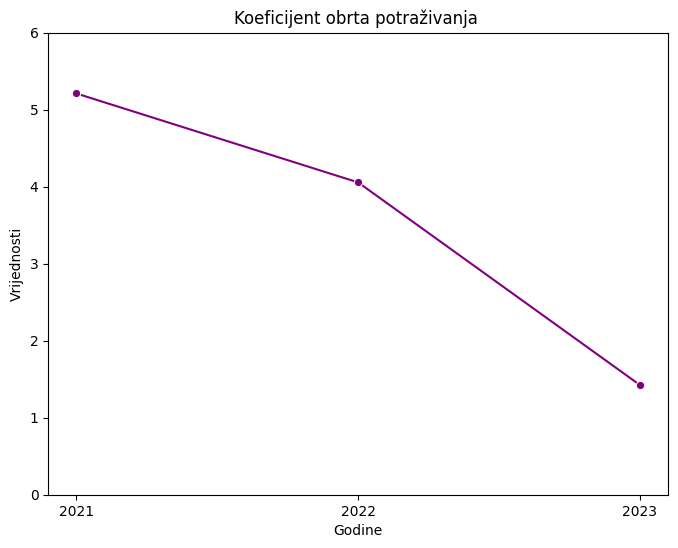

In [140]:
years = [2021, 2022, 2023]
koi = [5.211066, 4.056027, 1.42417]


plt.figure(figsize=(8, 6))

sns.lineplot(x=years, y=koi, marker='o', color='purple')

plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 7, 1))   # Postavljanje y-osi do 13
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Koeficijent obrta potraživanja ')

plt.show()

In [45]:
Dani_vezivanja_potraživanja = 365 / Koeficijent_potraživanja
Dani_vezivanja_potraživanja = pd.DataFrame (Dani_vezivanja_potraživanja)
Dani_vezivanja_potraživanja.columns = ['Dani vezivanja potraživanjа']
Dani_vezivanja_potraživanja

,Dani vezivanja potraživanjа
2021,70.043256
2022,89.989531
2023,256.289706


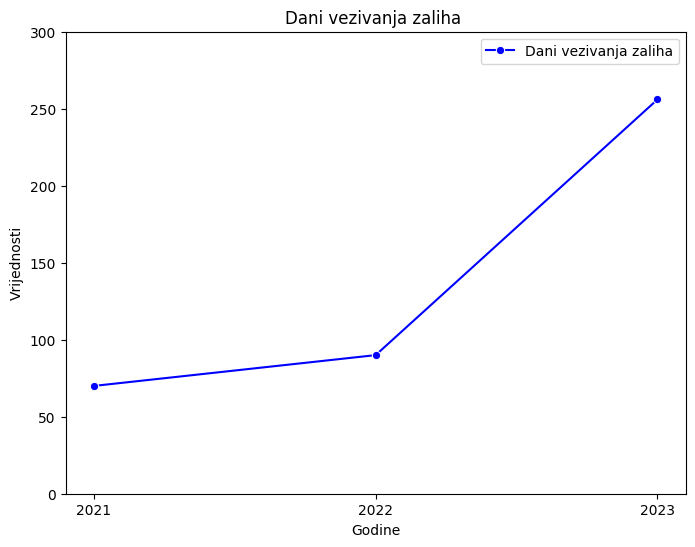

In [46]:
years = [2021, 2022, 2023]
dvoi = [70, 90, 256]


# Kreiranje grafika
plt.figure(figsize=(8, 6))

# Linija za tekuću likvidnost
sns.lineplot(x=years, y=dvoi, marker='o', color='blue', label='Dani vezivanja zaliha')


# Postavke za x- i y-ose
plt.xticks(years)  # Prikaz samo godina na x-osi
plt.yticks(np.arange(0, 301, 50))   # Postavljanje y-osi do 13

# Oznake
plt.xlabel('Godine')
plt.ylabel('Vrijednosti')
plt.title('Dani vezivanja zaliha ')

# Prikaz legende
plt.legend()

# Prikaz grafika
plt.show()

# STRUKTURA POSLOVNIH PRIHODA I RASHODA

#### STRUKTURA POSLOVNIH PRIHODA

In [155]:
prihodi_od_prodajeRobe =bu.loc[2, [2021 ,2022, 2023]]
prihodi_od_prodajeProizvoda = bu.loc[3, [2021 ,2022, 2023]]
pp = bu.loc[2:9, ['Pozicija' ,2021 ,2022, 2023]]
pp = pp.replace(' ', 0).infer_objects(copy=False).fillna(0)
pp


C:\Users\User\AppData\Local\Temp\ipykernel_15188\161435457.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pp = pp.replace(' ', 0).infer_objects(copy=False).fillna(0)


,Pozicija,2021,2022,2023
2,1 Prihodi od prodaje robe (203 do 205),0.0,0.0,0.0
3,2 Prihodi od prodaje proizvoda (207 do 209),7336654.0,5276054.0,4364253.0
4,3 Prihodi od pruženih usluga (211 do 213),0.0,5639854.0,6579087.0
5,4 Povećanje vrijednosti zaliha učinaka,0.0,0.0,0.0
6,5 Smanjenje vrijednosti zaliha učinaka,0.0,0.0,0.0
7,6 Povećanje vrijednosti investicionih nekretni...,0.0,0.0,0.0
8,7 Smanjenje vrijednosti investicionih nekretn...,0.0,0.0,0.0
9,8 Ostali poslovni prihodi,48000.0,79103.0,0.0


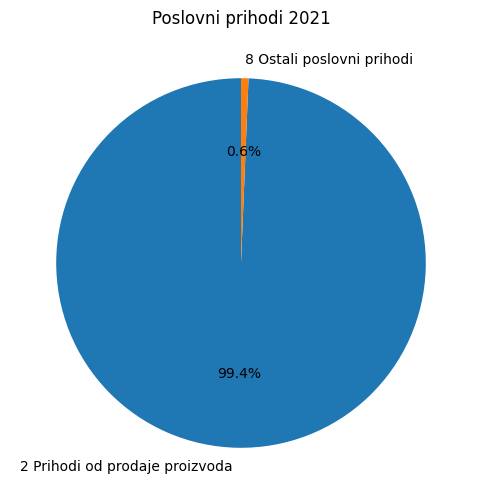

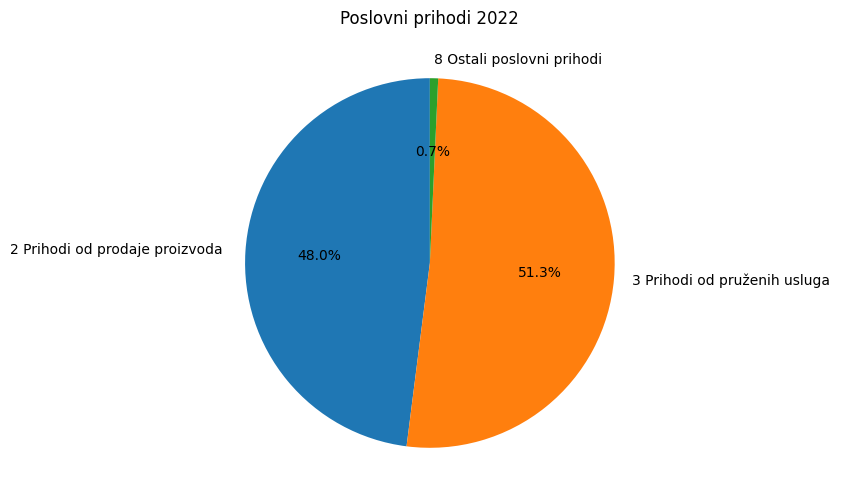

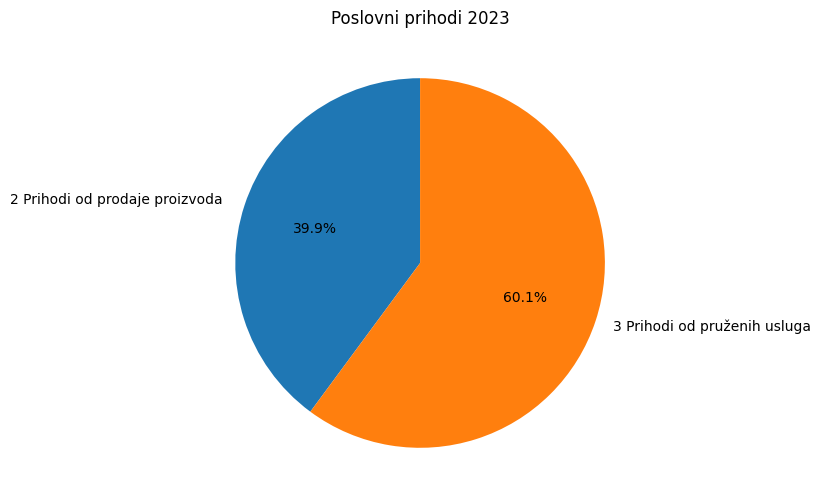

In [48]:
data = {
    'Pozicija': ['1 Prihodi od prodaje robe ',
                 '2 Prihodi od prodaje proizvoda ',
                 '3 Prihodi od pruženih usluga ',
                 '4 Povećanje vrijednosti zaliha učinaka',
                 '5 Smanjenje vrijednosti zaliha učinaka',
                 '6 Povećanje vrijednosti investicionih nekretnitnina',
                 '7 Smanjenje vrijednosti investicionih nekretnina',
                 '8 Ostali poslovni prihodi'],
    2021: [None, 7336654.0, None, None, None, None, None, 48000.0],
    2022: [None, 5276054.0, 5639854.0, None, None, None, None, 79103.0],
    2023: [None, 4364253, 6579087, None, None, None, None, None]
}

df = pd.DataFrame(data)
df.fillna(0, inplace=True)

# Funkcija za pie chart po godinama
def plot_pie_chart(year):
    # Izračunaj ukupne prihode za datu godinu
    poslovni_prihod = df[year].sum()
    
    # Izračunaj procente
    percentages = (df[year] / poslovni_prihod) * 100
    
    # Filtriraj samo stavke koje imaju veće od 0 prihoda
    non_zero_percentages = percentages[percentages > 0]
    labels = df.loc[non_zero_percentages.index, 'Pozicija']
    
    # Pie grafikon
    plt.figure(figsize=(6, 6))
    plt.pie(non_zero_percentages, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f'Poslovni prihodi {year}')
    plt.show()
plot_pie_chart(2021)
plot_pie_chart(2022)
plot_pie_chart(2023)

In [142]:
poslovni_prihodi_2021 = (bu.loc[3,  2021] + bu.loc[9,  2021])
poslovni_prihodi_2022 = (bu.loc[3,  2022] + bu.loc[4,  2022] +  bu.loc[9,  2022])
poslovni_prihodi_2023 = (bu.loc[3,  2023] + bu.loc[4,  2023])
poslovni_prihodi = [poslovni_prihodi_2021, poslovni_prihodi_2022, poslovni_prihodi_2023]
poslovni_prihodi_series = pd.Series(poslovni_prihodi, index=[2021, 2022, 2023])
poslovni_prihodi_series


2021     7384654.0
2022    10995011.0
2023    10943340.0
dtype: float64

In [148]:
bu.loc[9, [2021, 2022, 2023]] = bu.loc[9, [2021, 2022, 2023]].replace(' ', float('nan')).infer_objects(copy=False)
bu.loc[9, [2021, 2022, 2023]] = bu.loc[9, [2021, 2022, 2023]].astype(float)

In [147]:
bu.loc[3, [2021, 2022, 2023]] = bu.loc[3, [2021, 2022, 2023]].astype(float)
bu.loc[4, [2021, 2022, 2023]] = bu.loc[4, [2021, 2022, 2023]].astype(float)
bu.loc[9, [2021, 2022, 2023]] = bu.loc[9, [2021, 2022, 2023]].astype(float)
poslovni_prihodi_series = poslovni_prihodi_series.astype(float)


Učešće_PODP=(bu.loc[3,  [2021, 2022, 2023]] / poslovni_prihodi_series) * 100
Učešće_POPU=(bu.loc[4,  [2021, 2022, 2023]] / poslovni_prihodi_series) * 100
Učešće_OP=(bu.loc[9,  [2021, 2022, 2023]] / poslovni_prihodi_series) * 100

#Učešće_OP = Učešće_OP.to_frame()


Učešće_PODP =  Učešće_PODP.to_frame()
Učešće_PODP.columns = ['Učešće prodaje od prozivoda u poslovnim prihodima']
print(pd.DataFrame(Učešće_PODP))

Učešće_POPU = Učešće_POPU.to_frame()
Učešće_POPU.columns = ['Učešće prodaje od pruženih usluga u poslovnim prihodima']
pd.DataFrame(Učešće_POPU)

     Učešće prodaje od prozivoda u poslovnim prihodima
2021                                         99.350003
2022                                         47.985891
2023                                         39.880448


,Učešće prodaje od pruženih usluga u poslovnim prihodima
2021,NaN
2022,51.294664
2023,60.119552


#### STRUKTURA POSLOVNIH RASHODA

In [156]:
indeksi = [11, 12, 13, 14, 17, 18, 25, 26, 27]
poslovni_rashodi = bu.loc[indeksi]
poslovni_rashodi

,Pozicija,2023,2022,2021
11,1 Nabavna vrijednost prodate robe,,,NaN
12,2 Troškovi materijala,2477803,3419242,2264972.0
13,3 Troškovi goriva i energije,232355,31157,210272.0
14,"4 Troškovi plata, naknada plata i ostalih ličn...",3050344,2789883,2668750.0
17,5 Troškovi proizvodnih usluga,903352,1158948,857833.0
18,6 Troškovi amortizacije i rezervisanja (228 + ...,837155,801797,611005.0
25,7 Nematerijalni Troškovi (bez poreza i doprino...,313092,272785,425426.0
26,8 Troškovi poreza,19183,22226,11363.0
27,9 Troškovi doprinosa,,,NaN


In [160]:
data = {
    'Pozicija': ['Nabavna vrijednost prodate robe ',
                 'Troškovi materijala ',
                 'Troškovi goriva i energije ',
                 'Troškovi plata, naknada plata i ostalih ličnih rashoda',
                 'Troškovi proizvodnih usluga',
                 'Troškovi amortizacije i rezervisanja ',
                 'Nematerijalni Troškovi ',
                 'Nematerijalni Troškovi ',
                  'Troškovi doprinosa'  ],
    2021: [None, 2264972, 210272, 2668750, 857833, 611005, 425426, 11363, None],
    2022: [None, 3419242, 31157, 2789883, 1158948, 801797, 272785, 22226, None],
    2023: [None, 2477803, 232355, 3050344, 903352, 837155,313092, 19183, None]
}

# Kreiraj DataFrame
poslovni_rashodi = pd.DataFrame(data)

ukupni_rashodi_po_godinama = poslovni_rashodi[[2021, 2022, 2023]].sum()

procenti_po_indeksima = poslovni_rashodi[[2021, 2022, 2023]].div(ukupni_rashodi_po_godinama) * 100

procenti_po_indeksima['Pozicija'] = poslovni_rashodi['Pozicija']

procenti_po_indeksima = procenti_po_indeksima[['Pozicija', 2021, 2022, 2023]]
# Zaokruži procente na dvije decimale
procenti_po_indeksima[[2021, 2022, 2023]] = procenti_po_indeksima[[2021, 2022, 2023]].round(2)

# Prikaz rezultata
procenti_po_indeksima.fillna(0)


,Pozicija,2021,2022,2023
0,Nabavna vrijednost prodate robe,0.00,0.00,0.00
1,Troškovi materijala,32.13,40.25,31.63
2,Troškovi goriva i energije,2.98,0.37,2.97
3,"Troškovi plata, naknada plata i ostalih ličnih...",37.86,32.84,38.94
4,Troškovi proizvodnih usluga,12.17,13.64,11.53
5,Troškovi amortizacije i rezervisanja,8.67,9.44,10.69
6,Nematerijalni Troškovi,6.03,3.21,4.00
7,Nematerijalni Troškovi,0.16,0.26,0.24
8,Troškovi doprinosa,0.00,0.00,0.00


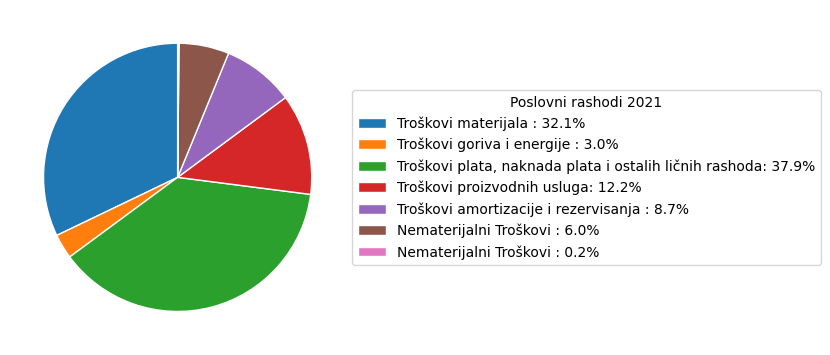

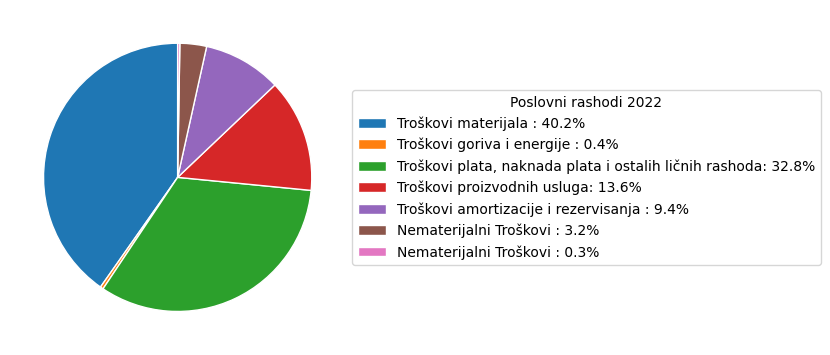

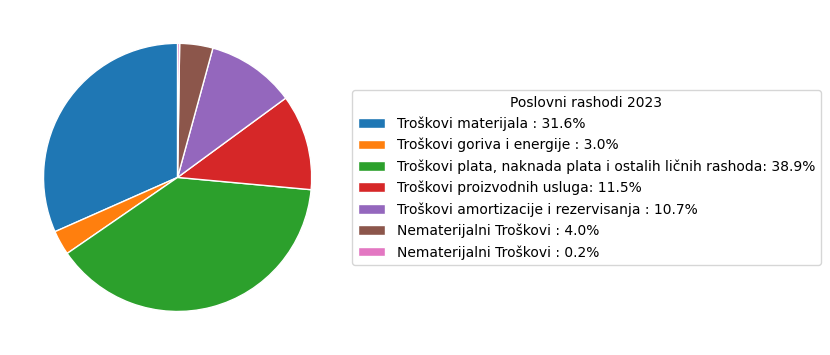

In [161]:
data = {
    'Pozicija': ['Nabavna vrijednost prodate robe ',
                 'Troškovi materijala ',
                 'Troškovi goriva i energije ',
                 'Troškovi plata, naknada plata i ostalih ličnih rashoda',
                 'Troškovi proizvodnih usluga',
                 'Troškovi amortizacije i rezervisanja ',
                 'Nematerijalni Troškovi ',
                 'Nematerijalni Troškovi ',
                  'Troškovi doprinosa'  ],
    2021: [None, 2264972, 210272, 2668750, 857833, 611005, 425426, 11363, None],
    2022: [None, 3419242, 31157, 2789883, 1158948, 801797, 272785, 22226, None],
    2023: [None, 2477803, 232355, 3050344, 903352, 837155,313092, 19183, None]
}

df = pd.DataFrame(data)

# Zamjena NaN vrijednosti sa 0
df.fillna(0, inplace=True)

# Funkcija za pie chart sa legendom
def plot_pie_chart_with_legend(year):
    # Izračunaj ukupne prihode za datu godinu
    total_revenue = df[year].sum()
    
    # Izračunaj procente
    percentages = (df[year] / total_revenue) * 100
    
    # Filtriraj samo stavke koje imaju veće od 0 prihoda
    non_zero_percentages = percentages[percentages > 0]
    labels = df.loc[non_zero_percentages.index, 'Pozicija']
    
    # Pie grafikon bez etiketa, samo procente
    plt.figure(figsize=(8, 7))
    wedges, _ = plt.pie(
        non_zero_percentages, 
        startangle=90, 
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )
    
    # Dodaj legendu
    plt.legend(wedges, [f"{label}: {pct:.1f}%" for label, pct in zip(labels, non_zero_percentages)],
               title=f'Poslovni rashodi {year}', loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    plt.tight_layout()  # Poboljšava raspored grafikona
    plt.show()

# Prikaz za 2021
plot_pie_chart_with_legend(2021)

# Prikaz za 2022
plot_pie_chart_with_legend(2022)

# Prikaz za 2023
plot_pie_chart_with_legend(2023)

# PROFITABILNOST PREDUZEĆA

In [ ]:
bu.head(200)

In [162]:
Neto_dobitak_gubitak = bu.loc[89:90, [2021, 2022, 2023]].apply(pd.to_numeric, errors='coerce').fillna(0)

# Izračunaj UKUPAN_ND_U_OBRAČUNSKOM_PERIODU oduzimanjem
UKUPAN_ND_U_OBRAČUNSKOM_PERIODU = Neto_dobitak_gubitak.loc[89, [2021, 2022, 2023]] - Neto_dobitak_gubitak.loc[90, [2021, 2022, 2023]]

# Dodaj kolonu 'Pozicija' nazad
UKUPAN_ND_U_OBRAČUNSKOM_PERIODU['Pozicija'] = bu.loc[89, 'Pozicija']


# Kreiraj DataFrame i prikaži rezultat
UKUPAN_ND_U_OBRAČUNSKOM_PERIODU_df = pd.DataFrame(UKUPAN_ND_U_OBRAČUNSKOM_PERIODU).T
UKUPAN_ND_U_OBRAČUNSKOM_PERIODU_df = UKUPAN_ND_U_OBRAČUNSKOM_PERIODU_df[['Pozicija', 2021, 2022, 2023]]

UKUPAN_ND_U_OBRAČUNSKOM_PERIODU_df

,Pozicija,2021,2022,2023
0,NJ NETO DOBIT I NETO GUBITAK PERIODA \n1 Neto ...,120037.0,2074298.0,2936593.0


In [177]:
Ukupni_prihodi=bu.loc[78, [2021,2022,2023]]
UKUPAN_ND_U_OBRAČUNSKOM_PERIODU = Neto_dobitak_gubitak.loc[89, [2021, 2022, 2023]] - Neto_dobitak_gubitak.loc[90, [2021, 2022, 2023]]
Koeficijent_profitabilnosti_copy = (UKUPAN_ND_U_OBRAČUNSKOM_PERIODU / Ukupni_prihodi)
Koeficijent_profitabilnosti = (UKUPAN_ND_U_OBRAČUNSKOM_PERIODU / Ukupni_prihodi).to_frame()

Koeficijent_profitabilnosti1 = pd.DataFrame ({
    'Ukupan neto dobitak u obračunskom periodu' : UKUPAN_ND_U_OBRAČUNSKOM_PERIODU,
    'Ukupni prihodi' : Ukupni_prihodi,
    'Koeficijent profitabilnosti' : Koeficijent_profitabilnosti_copy
}).T
Koeficijent_profitabilnosti1


,2021,2022,2023
Ukupan neto dobitak u obračunskom periodu,120037.0,2074298.0,2936593.0
Ukupni prihodi,7451511.0,11045905,11108564
Koeficijent profitabilnosti,0.016109,0.187789,0.264354


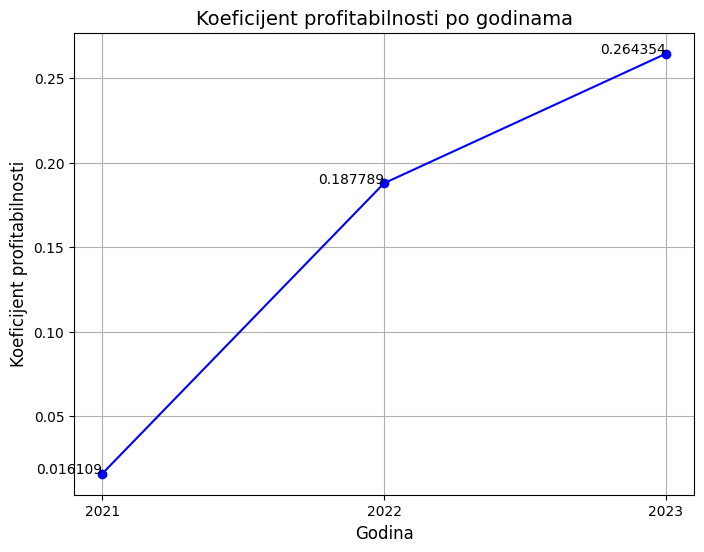

In [185]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
godina = [2021, 2022, 2023]

plt.plot(Koeficijent_profitabilnosti1.columns, Koeficijent_profitabilnosti1.loc['Koeficijent profitabilnosti'], marker='o', linestyle='-', color='b')

plt.title('Koeficijent profitabilnosti po godinama', fontsize=14)
plt.xlabel('Godina', fontsize=12)
plt.ylabel('Koeficijent profitabilnosti', fontsize=12)

plt.xticks(godina) 

for year, value in Koeficijent_profitabilnosti1.loc['Koeficijent profitabilnosti'].items():
    plt.text(year, value, f'{value:.6f}', fontsize=10, ha='right')

plt.grid(True)
plt.show()

# RIZIK OSTVARENJA FINANSIJSKOG REZULTATA

In [188]:
poslovni_prihodi_2021 = (bu.loc[3,  2021] + bu.loc[9,  2021])
poslovni_prihodi_2022 = (bu.loc[3,  2022] + bu.loc[4,  2022] +  bu.loc[9,  2022])
poslovni_prihodi_2023 = (bu.loc[3,  2023] + bu.loc[4,  2023])
poslovni_prihodi = [poslovni_prihodi_2021, poslovni_prihodi_2022, poslovni_prihodi_2023]
poslovni_prihodi
Varijabilni_troskovi=bu.loc[18, [2021, 2022, 2023]] + bu.loc[25, [2021, 2022, 2023]] + bu.loc[26, [2021, 2022, 2023]]
Marža_pokrića = poslovni_prihodi - Varijabilni_troskovi
Fiksni_i_pretFiksni_rashodi = bu.loc[12:14, [2021, 2022, 2023]].sum() + bu.loc[17, [2021, 2022, 2023]]
Rashodi_kamata = bu.loc[36, [2021, 2022, 2023]].fillna(0).apply(pd.to_numeric, errors='coerce').fillna(0)
Poslovni_rezultat = Marža_pokrića  - Fiksni_i_pretFiksni_rashodi
Bruto_finansijski_rezultat = Poslovni_rezultat - Rashodi_kamata
Bruto_finansijski_rezultat

Pozicije = [poslovni_prihodi, Varijabilni_troskovi,  Marža_pokrića, Fiksni_i_pretFiksni_rashodi,
           Rashodi_kamata, Poslovni_rezultat, Bruto_finansijski_rezultat]
Pozicije = pd.DataFrame(Pozicije)
Pozicije.columns = [2021, 2022, 2023]
pozicije_nazivi = ['Poslovni prihodi', 'Varijabilni troškovi', 'Marža pokrića', 
                   'Fiksni i pretežno fiksni rashodi', 'Rashodi kamata', 
                   'Poslovni rezultat', 'Bruto finansijski rezultat']
Pozicije.insert(0, 'Pozicija', pozicije_nazivi)
Pozicije







,Pozicija,2021,2022,2023
0,Poslovni prihodi,7384654.0,10995011.0,10943340.0
1,Varijabilni troškovi,1047794.0,1096808.0,1169430.0
2,Marža pokrića,6336860.0,9898203.0,9773910.0
3,Fiksni i pretežno fiksni rashodi,6001827.0,7399230.0,6663854.0
4,Rashodi kamata,0.0,0.0,43.0
5,Poslovni rezultat,335033.0,2498973.0,3110056.0
6,Bruto finansijski rezultat,335033.0,2498973.0,3110013.0


#### FAKTORI RIZIKA

In [189]:
Faktor_poslovnog_rizika = Marža_pokrića / Poslovni_rezultat
Faktor_finansijskog_rizika = Poslovni_rezultat / Bruto_finansijski_rezultat
Ukupni_rizik = Faktor_poslovnog_rizika * Faktor_finansijskog_rizika


Ukupni_rizici = [Faktor_poslovnog_rizika, Faktor_finansijskog_rizika, Ukupni_rizik ]
Ukupni_rizici = pd.DataFrame (Ukupni_rizici)
Ukupni_rizici.columns = [2021, 2022, 2023]
Nazivi_rizika = ['Faktor poslovnog rizika', 'Faktor finansijskog rizika','Ukupni rizik' ]
Ukupni_rizici.insert(0, 'Pozicija', Nazivi_rizika)
Ukupni_rizici

,Pozicija,2021,2022,2023
0,Faktor poslovnog rizika,18.914137,3.960908,3.142680
1,Faktor finansijskog rizika,1.000000,1.000000,1.000014
2,Ukupni rizik,18.914137,3.960908,3.142723


In [192]:
#Faktor_poslovnog_rizika = pd.DataFrame (Faktor_poslovnog_rizika)
#Faktor_poslovnog_rizika.columns = ['Faktor poslovnog rizika']
#Faktor_poslovnog_rizika

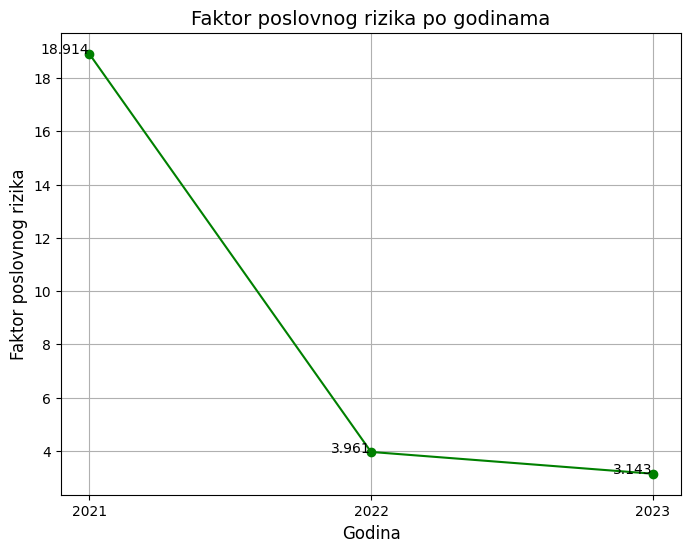

In [193]:

# Kreiranje grafikona
plt.figure(figsize=(8, 6))
plt.plot(Faktor_poslovnog_rizika.index, Faktor_poslovnog_rizika['Faktor poslovnog rizika'], marker='o', linestyle='-', color='g')

# Dodavanje naslova i oznaka osi
plt.title('Faktor poslovnog rizika po godinama', fontsize=14)
plt.xlabel('Godina', fontsize=12)
plt.ylabel('Faktor poslovnog rizika', fontsize=12)

# Postavljanje godina na x-osi
plt.xticks([2021, 2022, 2023])  # Samo godine bez decimalnih vrijednosti

# Prikazivanje vrijednosti na tačkama sa tri decimale
for year, value in Faktor_poslovnog_rizika['Faktor poslovnog rizika'].items():
    plt.text(year, value, f'{value:.3f}', fontsize=10, ha='right')

# Prikazivanje grafikona
plt.grid(True)
plt.show()

In [194]:
Ukupni_rizik = pd.DataFrame (Ukupni_rizik)
Ukupni_rizik.columns = ['Ukupni rizik']
Ukupni_rizik

,Ukupni rizik
2021,18.914137
2022,3.960908
2023,3.142723


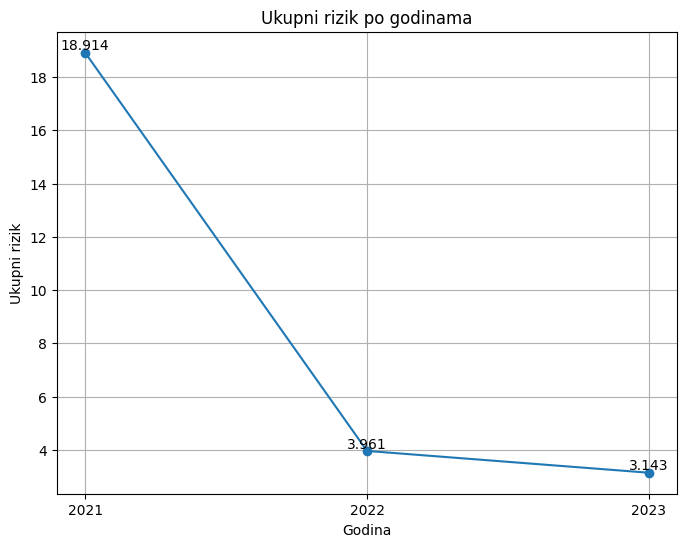

In [195]:
Ukupni_rizik_rounded = Ukupni_rizik.round(3)

# Kreiranje linijskog grafikona
plt.figure(figsize=(8, 6))
plt.plot(Ukupni_rizik_rounded.index, Ukupni_rizik_rounded['Ukupni rizik'], marker='o')

for i, value in enumerate(Ukupni_rizik_rounded['Ukupni rizik']):
    plt.text(Ukupni_rizik_rounded.index[i], value, f'{value:.3f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Ukupni rizik')
plt.title('Ukupni rizik po godinama')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()

In [196]:
Koeficijent_marze_pokrica = Marža_pokrića / poslovni_prihodi
Koeficijent_marze_pokrica = pd.DataFrame (Koeficijent_marze_pokrica)
Koeficijent_marze_pokrica.columns=['Koeficijent marže pokrića']
Koeficijent_marze_pokrica

,Koeficijent marže pokrića
2021,0.858112
2022,0.900245
2023,0.893138


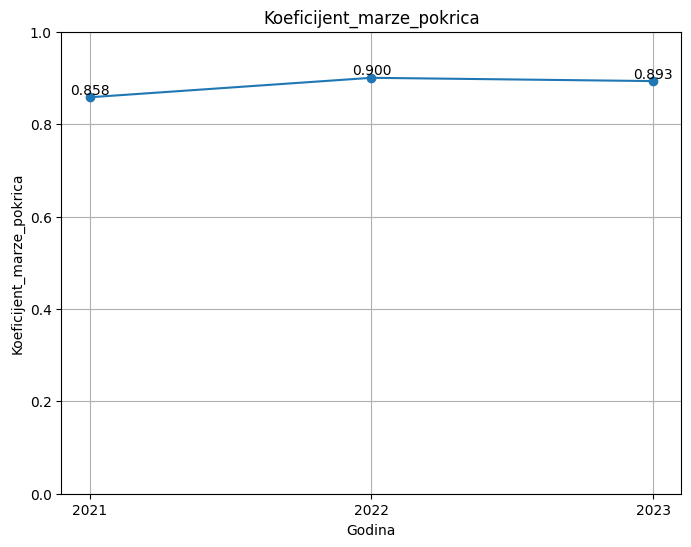

In [197]:
Koeficijent_marze_pokrica = Marža_pokrića / poslovni_prihodi
Koeficijent_marze_pokrica = pd.DataFrame (Koeficijent_marze_pokrica)
Koeficijent_marze_pokrica.columns=['Koeficijent marže pokrića']
Koeficijent_marze_pokrica

Koeficijent_marze_pokrica_rounded = Koeficijent_marze_pokrica.round(3)

# Kreiranje linijskog grafikona
plt.figure(figsize=(8, 6))
plt.plot(Koeficijent_marze_pokrica_rounded.index, Koeficijent_marze_pokrica_rounded['Koeficijent marže pokrića'], marker='o')

for i, value in enumerate(Koeficijent_marze_pokrica_rounded['Koeficijent marže pokrića']):
    plt.text(Koeficijent_marze_pokrica_rounded.index[i], value, f'{value:.3f}', ha='center', va='bottom')
    
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent_marze_pokrica')
plt.title('Koeficijent_marze_pokrica')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()

In [198]:
Potreban_prihod_NPD = Fiksni_i_pretFiksni_rashodi / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_NPD_Copy = Fiksni_i_pretFiksni_rashodi / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_NPD = pd.DataFrame (Potreban_prihod_NPD)
Potreban_prihod_NPD.columns = ['Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka']
Potreban_prihod_NPD


,Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka
2021,6994223.600152
2022,8219129.799776
2023,7461171.632679


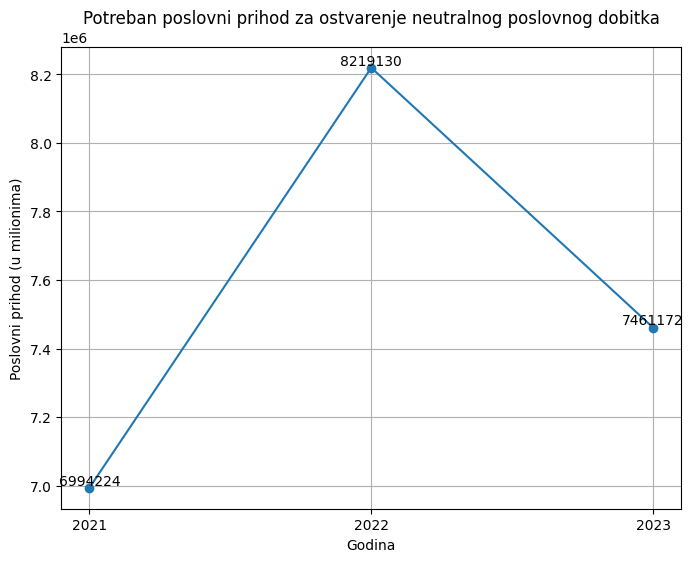

In [199]:
Potreban_prihod_NPD = Fiksni_i_pretFiksni_rashodi / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_NPD = pd.DataFrame (Potreban_prihod_NPD)
Potreban_prihod_NPD.columns = ['Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka']
Potreban_prihod_NPD


plt.figure(figsize=(8, 6))
plt.plot(Potreban_prihod_NPD.index, Potreban_prihod_NPD['Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka'], marker='o')

for i, value in enumerate(Potreban_prihod_NPD['Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka']):
    plt.text(Potreban_prihod_NPD.index[i], value, f'{value:.0f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Poslovni prihod (u milionima)')
plt.title('Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()


In [200]:
Stopa_ELPD=((poslovni_prihodi - Potreban_prihod_NPD_Copy) / poslovni_prihodi) * 100
Stopa_ELPD = pd.DataFrame (Stopa_ELPD)
Stopa_ELPD.columns = ['Stopa elastičnosti ostvarenja neutralnog dobitka']
Stopa_ELPD

,Stopa elastičnosti ostvarenja neutralnog dobitka
2021,5.287051
2022,25.246734
2023,31.819978


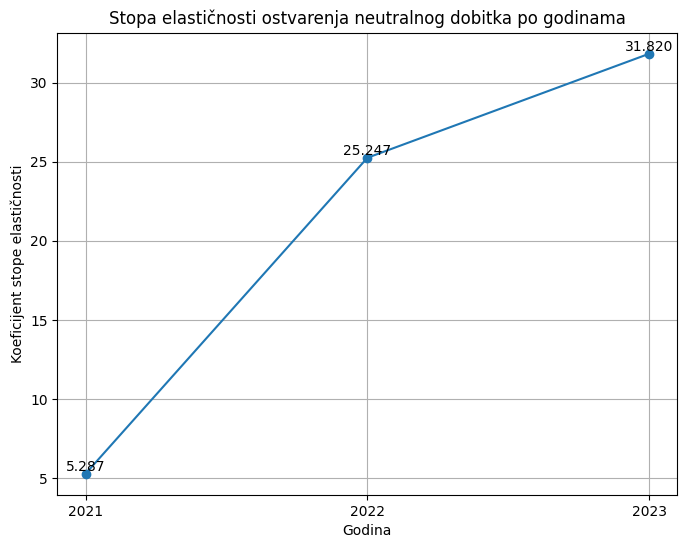

In [201]:
Potreban_prihod_NPD_Copy = Fiksni_i_pretFiksni_rashodi / (Marža_pokrića / poslovni_prihodi)
Stopa_ELPD=((poslovni_prihodi - Potreban_prihod_NPD_Copy) / poslovni_prihodi) * 100
Stopa_ELPD = pd.DataFrame (Stopa_ELPD)
Stopa_ELPD.columns = ['Stopa elastičnosti ostvarenja neutralnog dobitka']
Stopa_ELPD

plt.figure(figsize=(8, 6))
plt.plot(Stopa_ELPD.index, Stopa_ELPD['Stopa elastičnosti ostvarenja neutralnog dobitka'], marker='o')

for i, value in enumerate(Stopa_ELPD['Stopa elastičnosti ostvarenja neutralnog dobitka']):
    plt.text(Stopa_ELPD.index[i], value, f'{value:.3f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent stope elastičnosti')
plt.title('Stopa elastičnosti ostvarenja neutralnog dobitka po godinama')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()



In [202]:
Potreban_prihod_ND_Red_aktivnosti = (Fiksni_i_pretFiksni_rashodi + Rashodi_kamata) / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_ND_Red_aktivnosti_Copy = (Fiksni_i_pretFiksni_rashodi + Rashodi_kamata) / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_ND_Red_aktivnosti = pd.DataFrame (Potreban_prihod_ND_Red_aktivnosti) 
Potreban_prihod_ND_Red_aktivnosti.columns = ['Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti']
Potreban_prihod_ND_Red_aktivnosti
                                            

,Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti
2021,6994223.600152
2022,8219129.799776
2023,7461219.777549


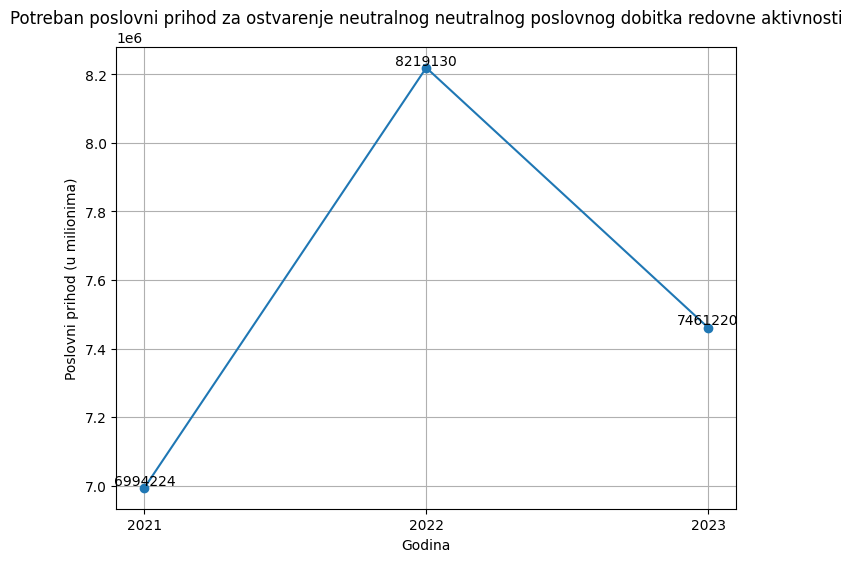

In [203]:
Potreban_prihod_ND_Red_aktivnosti = (Fiksni_i_pretFiksni_rashodi + Rashodi_kamata) / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_ND_Red_aktivnosti_Copy = (Fiksni_i_pretFiksni_rashodi + Rashodi_kamata) / (Marža_pokrića / poslovni_prihodi)
Potreban_prihod_ND_Red_aktivnosti = pd.DataFrame (Potreban_prihod_ND_Red_aktivnosti) 
Potreban_prihod_ND_Red_aktivnosti.columns = ['Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti']


plt.figure(figsize=(8, 6))
plt.plot(Potreban_prihod_ND_Red_aktivnosti.index, Potreban_prihod_ND_Red_aktivnosti['Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti'], marker='o')

for i, value in enumerate(Potreban_prihod_ND_Red_aktivnosti['Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti']):
    plt.text(Potreban_prihod_NPD.index[i], value, f'{value:.0f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Poslovni prihod (u milionima)')
plt.title('Potreban poslovni prihod za ostvarenje neutralnog neutralnog poslovnog dobitka redovne aktivnosti')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()


In [204]:
Stopa_ELNDRA = ((poslovni_prihodi - Potreban_prihod_ND_Red_aktivnosti_Copy)/poslovni_prihodi) * 100
Stopa_ELNDRA = pd.DataFrame (Stopa_ELNDRA)
Stopa_ELNDRA.columns = ['Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti']
Stopa_ELNDRA

,Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti
2021,5.287051
2022,25.246734
2023,31.819538


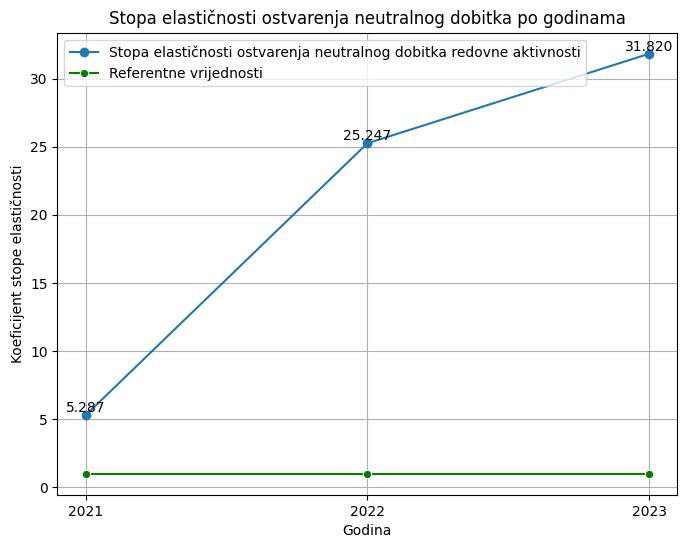

In [205]:
Potreban_prihod_ND_Red_aktivnosti_Copy = (Fiksni_i_pretFiksni_rashodi + Rashodi_kamata) / (Marža_pokrića / poslovni_prihodi)
Stopa_ELNDRA = ((poslovni_prihodi - Potreban_prihod_ND_Red_aktivnosti_Copy)/poslovni_prihodi) * 100
Stopa_ELNDRA = pd.DataFrame (Stopa_ELNDRA)
Stopa_ELNDRA.columns = ['Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti']
Stopa_ELNDRA

referentne_vrijednosti = [1, 1, 1]

plt.figure(figsize=(8, 6))
plt.plot(Stopa_ELNDRA.index, Stopa_ELNDRA['Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti'], marker='o', label='Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti')

sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')

for i, value in enumerate(Stopa_ELNDRA['Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti']):
    plt.text(Stopa_ELNDRA.index[i], value, f'{value:.3f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent stope elastičnosti')
plt.title('Stopa elastičnosti ostvarenja neutralnog dobitka po godinama')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()


In [206]:
spojen_df = pd.concat([Koeficijent_marze_pokrica, 
                         Potreban_prihod_NPD, 
                         Stopa_ELPD, 
                         Potreban_prihod_ND_Red_aktivnosti, 
                         Stopa_ELNDRA], axis=1).T
spojen_df

,2021,2022,2023
Koeficijent marže pokrića,0.858112,0.900245,0.893138
Potreban poslovni prihod za ostvarenje neutralnog poslovnog dobitka,6994223.600152,8219129.799776,7461171.632679
Stopa elastičnosti ostvarenja neutralnog dobitka,5.287051,25.246734,31.819978
Potreban prihod za ostvarenje neutralnog dobitka redovne aktivnosti,6994223.600152,8219129.799776,7461219.777549
Stopa elastičnosti ostvarenja neutralnog dobitka redovne aktivnosti,5.287051,25.246734,31.819538


# RENTABILNOST

In [208]:
Neto_dobitakILIgubitak = bu.loc[80, [2021, 2022, 2023]] - bu.loc[82, [2021, 2022, 2023]]
Rashodi_kamata
NETO_PRINOS_NA_UKUPNI_KAPITAL = Neto_dobitakILIgubitak + Rashodi_kamata

Prosječan_sopstveni_kapital_2023 = (bs.loc[69,  2023] + bs.loc[69,  2022]) / 2
Prosječan_sopstveni_kapital_2022 = (bs.loc[69,  2022] + bs.loc[69,  2021]) / 2
Prosječan_sopstveni_kapital_2021 = (bs.loc[69,  2022] + 2855317) / 2
Prosječni_sopstveni_kapital = [Prosječan_sopstveni_kapital_2021,  Prosječan_sopstveni_kapital_2022, Prosječan_sopstveni_kapital_2023]
Prosječni_sopstveni_kapital = pd.Series(Prosječni_sopstveni_kapital, index=[2021, 2022, 2023])

Prosječan_ukupan_kapital_2023 = (bs.loc[68,  2023] + bs.loc[68,  2022]) / 2
Prosječan_ukupan_kapital_2022 = (bs.loc[68,  2022] + bs.loc[68,  2021]) / 2
Prosječan_ukupan_kapital_2021 = (bs.loc[68,  2022] + 12440049) / 2
Prosječni_ukupan_kapital = [Prosječan_ukupan_kapital_2021,  Prosječan_ukupan_kapital_2022, Prosječan_ukupan_kapital_2023]
Prosječni_ukupan_kapital = pd.Series(Prosječni_ukupan_kapital, index=[2021, 2022, 2023])

Prosječan_invesitran_kapital_2023 = (bs.loc[68,  2023] + bs.loc[68,  2022]) / 2
Prosječan_investiran_kapital_2022 = (bs.loc[68,  2022] + bs.loc[68,  2021]) / 2
Prosječan_investiran_kapital_2021 = (bs.loc[68,  2022] + 12440049) / 2
Prosječan_investiran_kapital = [Prosječan_investiran_kapital_2021, Prosječan_investiran_kapital_2022, Prosječan_invesitran_kapital_2023]


In [209]:
Rentabilnost_sopstvenog_kapitala = (Neto_dobitakILIgubitak / Prosječni_sopstveni_kapital) * 100
Rentabilnost_sopstvenog_kapitala = pd.DataFrame (Rentabilnost_sopstvenog_kapitala)
Rentabilnost_sopstvenog_kapitala.columns = ['Rentabilnost sopstvenog kapitala']
Rentabilnost_sopstvenog_kapitala

,Rentabilnost sopstvenog kapitala
2021,4.203982
2022,72.646855
2023,102.846479


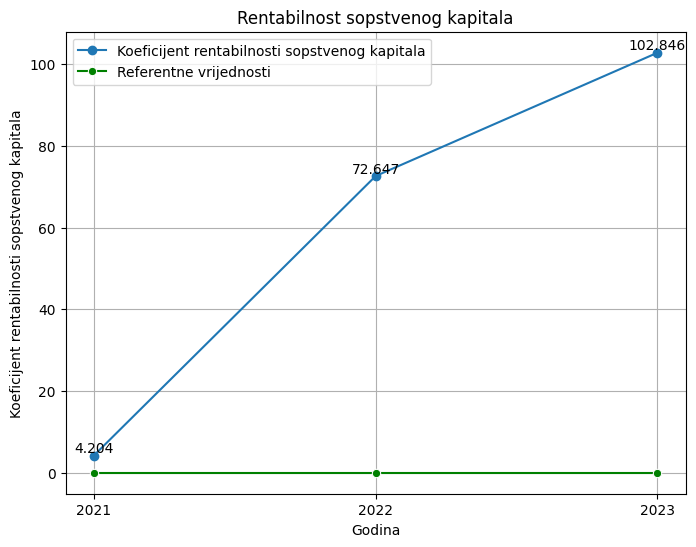

In [210]:
Rentabilnost_sopstvenog_kapitala = (Neto_dobitakILIgubitak / Prosječni_sopstveni_kapital) * 100
Rentabilnost_sopstvenog_kapitala = pd.DataFrame (Rentabilnost_sopstvenog_kapitala)
Rentabilnost_sopstvenog_kapitala.columns = ['Rentabilnost sopstvenog kapitala']
Rentabilnost_sopstvenog_kapitala

referentne_vrijednosti = [0, 0, 0]

plt.figure(figsize=(8, 6))
plt.plot(Rentabilnost_sopstvenog_kapitala.index, Rentabilnost_sopstvenog_kapitala['Rentabilnost sopstvenog kapitala'], marker='o', label='Koeficijent rentabilnosti sopstvenog kapitala')

sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')



for i, value in enumerate(Rentabilnost_sopstvenog_kapitala['Rentabilnost sopstvenog kapitala']):
    plt.text(Rentabilnost_sopstvenog_kapitala.index[i], value, f'{value:.3f}', ha='center', va='bottom')

# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent rentabilnosti sopstvenog kapitala')
plt.title('Rentabilnost sopstvenog kapitala')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()

In [211]:
Rentabilnost_ukupnog_kapitala =(NETO_PRINOS_NA_UKUPNI_KAPITAL / Prosječni_ukupan_kapital)*100
Rentabilnost_ukupnog_kapitala = pd.DataFrame(Rentabilnost_ukupnog_kapitala)
Rentabilnost_ukupnog_kapitala.columns = ['Rentabilnost ukupnog kapitala']
Rentabilnost_ukupnog_kapitala

,Rentabilnost ukupnog kapitala
2021,0.886718
2022,15.255293
2023,19.443646


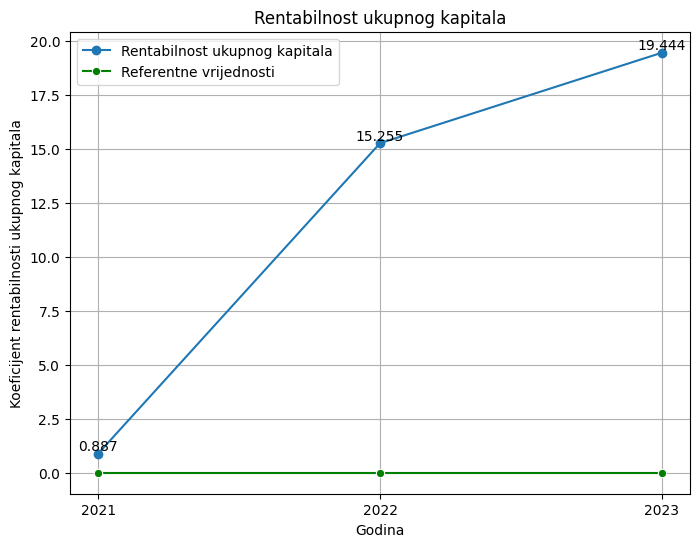

In [212]:
Rentabilnost_ukupnog_kapitala =(NETO_PRINOS_NA_UKUPNI_KAPITAL / Prosječni_ukupan_kapital)*100
Rentabilnost_ukupnog_kapitala = pd.DataFrame(Rentabilnost_ukupnog_kapitala)
Rentabilnost_ukupnog_kapitala.columns = ['Rentabilnost ukupnog kapitala']
Rentabilnost_ukupnog_kapitala

referentne_vrijednosti = [0, 0, 0]

plt.figure(figsize=(8, 6))
plt.plot(Rentabilnost_ukupnog_kapitala.index, Rentabilnost_ukupnog_kapitala['Rentabilnost ukupnog kapitala'], marker='o', label='Rentabilnost ukupnog kapitala')

for i, value in enumerate(Rentabilnost_ukupnog_kapitala['Rentabilnost ukupnog kapitala']):
    plt.text(Rentabilnost_ukupnog_kapitala.index[i], value, f'{value:.3f}', ha='center', va='bottom')

sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')



# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent rentabilnosti ukupnog kapitala')
plt.title('Rentabilnost ukupnog kapitala')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()



In [213]:
Rentabilnost_investiranog_kapitala = (NETO_PRINOS_NA_UKUPNI_KAPITAL / Prosječan_investiran_kapital)*100
Rentabilnost_investiranog_kapitala = pd.DataFrame(Rentabilnost_investiranog_kapitala)
Rentabilnost_investiranog_kapitala.columns = ['Rentabilnost investiranog kapitala']
Rentabilnost_investiranog_kapitala

,Rentabilnost investiranog kapitala
2021,0.886718
2022,15.255293
2023,19.443646


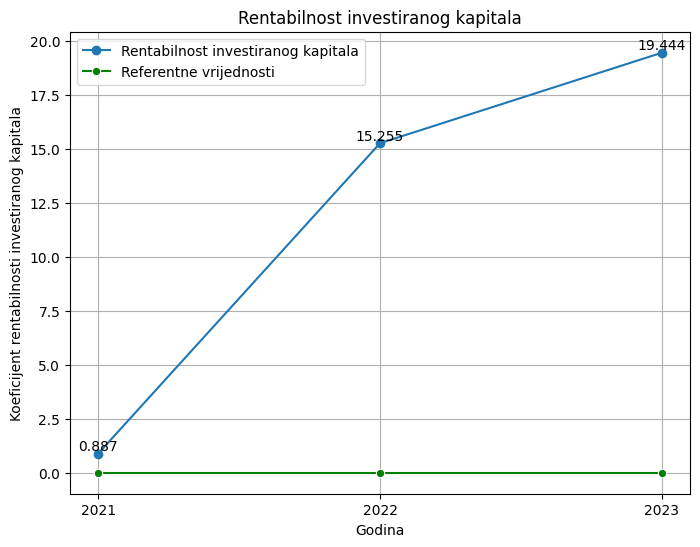

In [214]:
Rentabilnost_investiranog_kapitala =(NETO_PRINOS_NA_UKUPNI_KAPITAL / Prosječni_ukupan_kapital)*100
Rentabilnost_investiranog_kapitala = pd.DataFrame(Rentabilnost_investiranog_kapitala)
Rentabilnost_investiranog_kapitala.columns = ['Rentabilnost investiranog kapitala']
Rentabilnost_investiranog_kapitala

referentne_vrijednosti = [0, 0, 0]

plt.figure(figsize=(8, 6))
plt.plot(Rentabilnost_investiranog_kapitala.index, Rentabilnost_investiranog_kapitala['Rentabilnost investiranog kapitala'], marker='o', label='Rentabilnost investiranog kapitala')

for i, value in enumerate(Rentabilnost_investiranog_kapitala['Rentabilnost investiranog kapitala']):
    plt.text(Rentabilnost_investiranog_kapitala.index[i], value, f'{value:.3f}', ha='center', va='bottom')

sns.lineplot(x=years, y=referentne_vrijednosti, marker='o', color='g', label='Referentne vrijednosti')



# Podešavanje osi i etiketa
plt.xlabel('Godina')
plt.ylabel('Koeficijent rentabilnosti investiranog kapitala')
plt.title('Rentabilnost investiranog kapitala')
plt.xticks([2021, 2022, 2023])  # Postavljanje samo godina na x-osi
plt.grid(True)

# Prikaz grafikona
plt.show()


In [215]:
rentabilnost_df = pd.concat([Rentabilnost_sopstvenog_kapitala, Rentabilnost_ukupnog_kapitala, Rentabilnost_investiranog_kapitala ], axis = 1).T
rentabilnost_df

,2021,2022,2023
Rentabilnost sopstvenog kapitala,4.203982,72.646855,102.846479
Rentabilnost ukupnog kapitala,0.886718,15.255293,19.443646
Rentabilnost investiranog kapitala,0.886718,15.255293,19.443646


In [216]:
print(bs[bs['Pozicija'].str.contains('Stalna', na=False)])
print(bs[bs['Pozicija'].str.contains('OBAVEZE', na=False)])

                                             Pozicija 2021 2022  2023
42  Stalna sredstva namijenjena prodaji i sredstva...  NaN  NaN   NaN
                                              Pozicija     2021    2022  \
99   B DUGOROČNA REZERVISANJA I DUGOROČNE OBAVEZE (...      NaN     NaN   
104                  II DUGOROČNE OBAVEZE (138 do 144)      NaN     NaN   
113                         V ODLOŽENE PORESKE OBAVEZE      NaN     NaN   
114  G KRATKOROČNE OBAVEZE I KRATKOROČNA REZERVISAN...  1223620  893057   

          2023  
99         NaN  
104        NaN  
113        NaN  
114  1226400.0  


# ZETA ANALIZA

In [221]:
TRAJNI_I_DUGOROČNI_KAPITAL = Kapital + Rezervisanja_i_odloženiPoreskiPrihodi + dugoročne_obaveze
Stalna_imovina = bs.loc[1, [2021, 2022, 2023]]

NETO_OBRTNI_KAPITAL_copy = TRAJNI_I_DUGOROČNI_KAPITAL - Stalna_imovina
#NETO_OBRTNI_KAPITAL_copy = pd.DataFrame (NETO_OBRTNI_KAPITAL_copy)
Ukupna_aktiva =  bs.loc [66, [2021, 2022, 2023]]
X1 = NETO_OBRTNI_KAPITAL_copy / Ukupna_aktiva

Zadržana_dobit=bs.loc[91, [2021 ,2022, 2023]]
Ukupna_aktiva =  bs.loc [66, [2021, 2022, 2023]]
X2 = Zadržana_dobit / Ukupna_aktiva

EBIT = bu.loc[80, [2021,2022,2023]]
Ukupna_aktiva
X3 = EBIT / Ukupna_aktiva

Sopstveni_kapital = bs.loc[68, [2021, 2022,2023]]
Ukupne_obaveze = bs.loc[104, [2021, 2022, 2023]].fillna(0) + bs.loc[114, [2021, 2022, 2023]]
X4 = Sopstveni_kapital / Ukupne_obaveze



C:\Users\User\AppData\Local\Temp\ipykernel_15188\3096660783.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Ukupne_obaveze = bs.loc[104, [2021, 2022, 2023]].fillna(0) + bs.loc[114, [2021, 2022, 2023]]


In [225]:
Prihodi_od_prodaje = (bu.loc[3, [2021, 2022, 2023]].fillna(0)  + bu.loc[4, [2021, 2022, 2023]].fillna(0))
Ukupna_aktiva
X5 = Prihodi_od_prodaje / Ukupna_aktiva


C:\Users\User\AppData\Local\Temp\ipykernel_15188\2976621369.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Prihodi_od_prodaje = (bu.loc[3, [2021, 2022, 2023]].fillna(0)  + bu.loc[4, [2021, 2022, 2023]].fillna(0))
C:\Users\User\AppData\Local\Temp\ipykernel_15188\2976621369.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Prihodi_od_prodaje = (bu.loc[3, [2021, 2022, 2023]].fillna(0)  + bu.loc[4, [2021, 2022, 2023]].fillna(0))


In [219]:
NETO_OBRTNI_KAPITAL_copy = NETO_OBRTNI_KAPITAL_copy.squeeze()

In [226]:
df1 = pd.DataFrame({
    'I Neto obrtni kapital' : NETO_OBRTNI_KAPITAL_copy,
    'II Ukupna aktiva' : Ukupna_aktiva,
    'X1 (I/II)' : X1,
    'III Zadržana dobit': Zadržana_dobit,
    'IV Ukupna aktiva' : Ukupna_aktiva,
    'X2 (III/IV)' : X2,
    'V Dobit prije oporezivanja(EBIT)' : EBIT,
    'VI Ukupna aktiva' : Ukupna_aktiva,
    'X3 (V/VI) ' :  X3,
    'VII Tržišna vrijednost (Sopstveni kapital)' : Sopstveni_kapital,
    'VIII Ukupne obaveze' : Ukupne_obaveze,
    'X4 (VII / VIII) ' :  X4,
    'IX Prihodi od prodaje': Prihodi_od_prodaje,
    'X Ukupna aktiva': Ukupna_aktiva,
    'X5 (IX/X)': X5
}).T

df1

,2021,2022,2023
I Neto obrtni kapital,7587652,9864149,11513539.0
II Ukupna aktiva,13783706,15527441,16798656.0
X1 (I/II),0.55048,0.635272,0.685385
III Zadržana dobit,9018521,11092819,12030691.0
IV Ukupna aktiva,13783706,15527441,16798656.0
X2 (III/IV),0.654289,0.714401,0.71617
V Dobit prije oporezivanja(EBIT),120037.0,2240741,3269540
VI Ukupna aktiva,13783706,15527441,16798656.0
X3 (V/VI),0.008709,0.144308,0.194631
VII Tržišna vrijednost (Sopstveni kapital),12560086,14634384,15572256.0


In [227]:
Z_analiza = ((0.717*X1)+(0.847*X2)+(3.107*X3)+(0.420 * X4)+(0.948*X5))
Zeta_analiza = ((0.00717*X1)+(0.00847*X2)+(0.03107*X3)+(0.00420 * X4)+(0.00948*X5))

Z_i_zeta_analiza = pd.DataFrame ({
    'Z analiza' : Z_analiza,
    'Zeta analiza': Zeta_analiza
})
Z_i_zeta_analiza


,Z analiza,Zeta analiza
2021,5.791698,0.057917
2022,9.057879,0.090579
2023,7.653266,0.076533


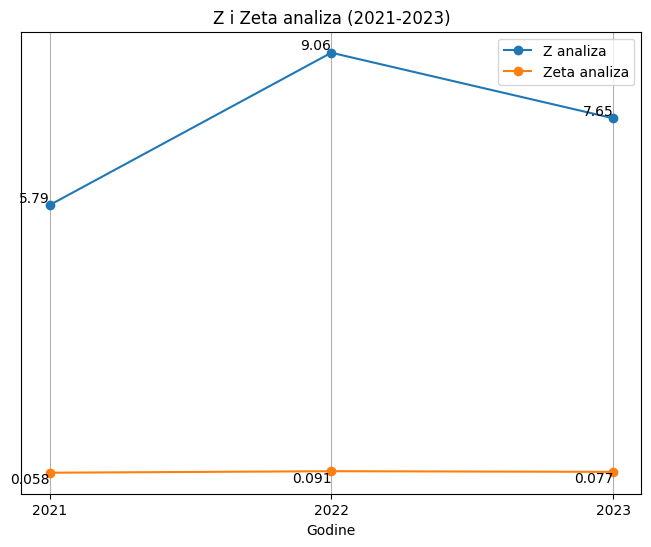

In [228]:
godine = [2021, 2022, 2023]
z_analiza = [5.791698, 9.057879, 7.653266]
zeta_analiza = [0.057917, 0.090579, 0.076533]

plt.figure(figsize=(8, 6))
plt.plot(godine, z_analiza, marker='o', label='Z analiza')
plt.plot(godine, zeta_analiza, marker='o', label='Zeta analiza')

# Dodavanje oznaka vrijednosti na tačke
for i, v in enumerate(z_analiza):
    plt.text(godine[i], v, f'{v:.2f}', ha='right', va='bottom')

for i, v in enumerate(zeta_analiza):
    plt.text(godine[i], v, f'{v:.3f}', ha='right', va='top')

# Dodavanje oznaka i legendi
plt.xticks(godine)  # Ograničavanje x-osi na godine bez decimalnih brojeva
plt.yticks([])  # Uklanjanje vrijednosti sa y-osi
plt.xlabel('Godine')
plt.ylabel('')  # Bez oznake na y-osi
plt.title('Z i Zeta analiza (2021-2023)')
plt.legend()

# Prikaz grafikona
plt.grid(True)
plt.show()

# ANALIZA NETO NOVČANOG TOKA

In [229]:
nt = pd.read_excel('izvjestaj_o_novcanim tokovima.xlsx')


In [230]:
print(nt[nt['Pozicija'].str.contains('Neto odliv gotovine iz aktivnosti investiranja', na=False)])


                                             Pozicija     2023      2022  \
42  Neto odliv gotovine iz aktivnosti investiranja...  74803.0  564839.0   

         2021  
42  1796906.0  


In [231]:
nt.tail(60
       )

,Pozicija,2023,2022,2021
8,Odlivi po osnovu plaćenih kamata,NaN,NaN,NaN
9,"Odlivi po osnovu isplata plata, naknada plata ...",3050344.0,2789883.0,2668750.0
10,Odlivi po osnovu poreza na dobit,58757.0,1966.0,7500.0
11,Ostali odlivi iz poslovnih aktivnosti,17585.0,74360.0,112591.0
12,Neto priliv gotovine iz poslovnih aktivnosti (...,804967.0,2721123.0,785437.0
13,Neto odliv gotovine iz poslovnih aktivnosti (5...,NaN,NaN,NaN
14,TOKOVI GOTOVINE IZ AKTIVNOSTI INVESTIRANJA Pri...,NaN,NaN,NaN
15,Prilivi gotovine po osnovu prodaje akcija i ud...,NaN,NaN,NaN
16,"Prilivi po osnovu prodaje nekretnina, postroje...",NaN,NaN,NaN
17,Prilivi po osnovu prodaje investicionih nekret...,NaN,NaN,NaN


In [232]:
Prilivi_poslovne_aktivnosti = nt.loc[0, [2021,2022,2023]]
Odlivi_poslovne_aktivnosti = nt.loc[5, [2021, 2022, 2023]]
Neto_priliv_odliv_poslovne_aktivnosti = Prilivi_poslovne_aktivnosti - Odlivi_poslovne_aktivnosti
Poslovna_aktivnost = pd.DataFrame ({
    'Prilivi poslovne aktivnosti' : Prilivi_poslovne_aktivnosti,
    'Odlivi_poslovne_aktivnosti' : Odlivi_poslovne_aktivnosti,
}).T

Prilivi_aktivnosti_investiranja = nt.loc[14, [2021,2022,2023]].fillna(0)
Odlivi_aktivnosti_investiranja = nt.loc[30, [2021, 2022, 2023]]
Neto_priliv_odliv_aktivnosti_investiranja = Prilivi_aktivnosti_investiranja - Odlivi_aktivnosti_investiranja
Aktivnost_investiranja = pd.DataFrame ({
    'Prilivi aktivnosti investiranja' : Prilivi_aktivnosti_investiranja,
    'Odlivi aktivnosti investiranja' : Odlivi_aktivnosti_investiranja,
}).T


Prilivi_aktivnosti_finansiranja = nt.loc[43, [2021,2022,2023]].fillna(0)
Odlivi_aktivnosti_finansiranja = nt.loc[50, [2021, 2022, 2023]]
Neto_priliv_odliv_aktivnosti_finansiranja = Prilivi_aktivnosti_finansiranja - Odlivi_aktivnosti_finansiranja
Aktivnost_investiranja = pd.DataFrame ({
    'Prilivi aktivnosti finansiranja' : Prilivi_aktivnosti_finansiranja,
    'Odlivi aktivnosti finansiranja' : Odlivi_aktivnosti_finansiranja,
}).T

Ukupni_prilivi = nt.loc[0, [2021,2022,2023]] + nt.loc[14, [2021,2022,2023]].fillna(0) + nt.loc[43, [2021,2022,2023]].fillna(0)
Ukupni_odlivi = nt.loc[5, [2021, 2022, 2023]] + nt.loc[30, [2021, 2022, 2023]] + nt.loc[50, [2021, 2022, 2023]]
a = Ukupni_prilivi - Ukupni_odlivi

NP_NO = pd.DataFrame({
    'Ukupni prilivi': Ukupni_prilivi,
    'Ukupni odlivi': Ukupni_odlivi,
    'Neto priliv gotovine': np.where(a > 0, a, 0),
    'Neto odliv gotovine': np.where(a < 0, -a, 0)
}).T

NP_NO

C:\Users\User\AppData\Local\Temp\ipykernel_15188\2105330076.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Prilivi_aktivnosti_investiranja = nt.loc[14, [2021,2022,2023]].fillna(0)
C:\Users\User\AppData\Local\Temp\ipykernel_15188\2105330076.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Prilivi_aktivnosti_finansiranja = nt.loc[43, [2021,2022,2023]].fillna(0)
C:\Users\User\AppData\Local\Temp\ipykernel_15188\2105330076.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versio

,2021,2022,2023
Ukupni prilivi,8640749.0,11513100.0,8922492.0
Ukupni odlivi,9217747.0,9362626.0,10218090.0
Neto priliv gotovine,0,2150474.0,0
Neto odliv gotovine,576998.0,0,1295598.0


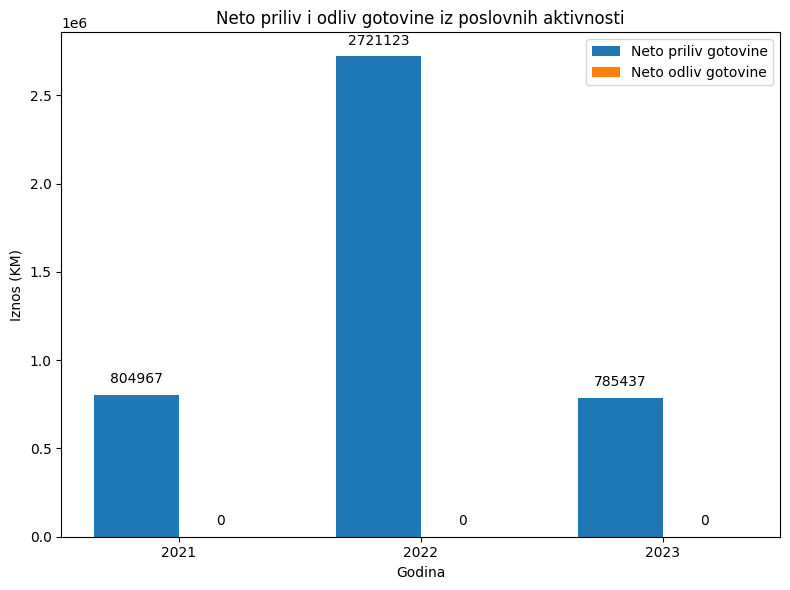

In [233]:
labels = ['2021', '2022', '2023']
priliv = [804967.0, 2721123.0, 785437.0]
odliv = [0, 0, 0]  # NaN vrijednosti se postavljaju na 0

# Kreiranje bara
x = np.arange(len(labels))
width = 0.35  # Širina bara

# Kreiranje bar grafikona
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, priliv, width, label='Neto priliv gotovine')
plt.bar(x + width/2, odliv, width, label='Neto odliv gotovine')

# Dodavanje oznaka na osi i naslov
plt.xlabel('Godina')
plt.ylabel('Iznos (KM)')
plt.title('Neto priliv i odliv gotovine iz poslovnih aktivnosti')
plt.xticks(x, labels)

# Dodavanje vrijednosti iznad bara
for i in range(len(labels)):
    plt.text(i - width/2, priliv[i] + 50000, f'{priliv[i]:.0f}', ha='center', va='bottom')
    plt.text(i + width/2, odliv[i] + 50000, f'{odliv[i]:.0f}', ha='center', va='bottom')

# Dodavanje legende
plt.legend()

# Prikaz grafikona
plt.tight_layout()
plt.show()

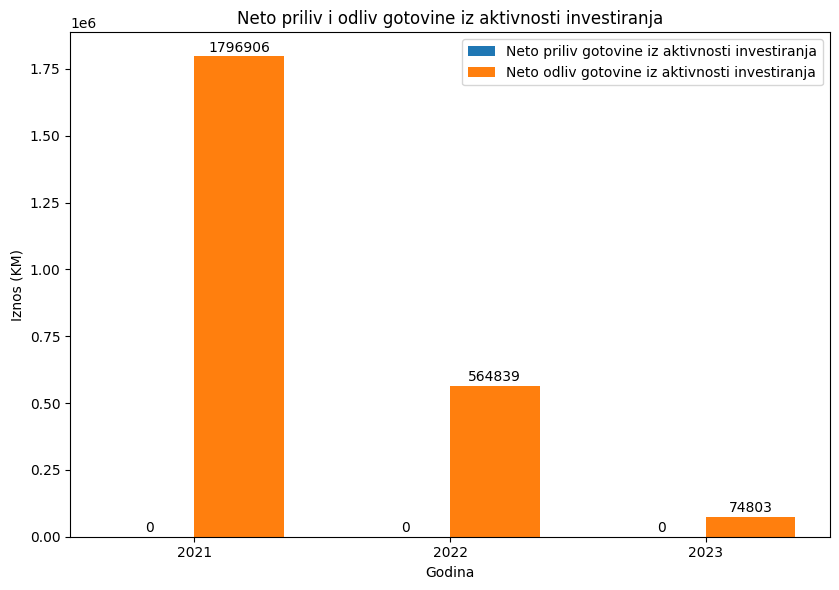

In [234]:
labels = ['2021', '2022', '2023']
priliv = [0.0, 0.0, 0.0]
odliv = [1796906, 564839, 74803]  # NaN vrijednosti se postavljaju na 0

# Kreiranje bara
x = np.arange(len(labels))
width = 0.35  # Širina bara

# Kreiranje bar grafikona
plt.figure(figsize=(8.5, 6))
plt.bar(x - width/2, priliv, width, label='Neto priliv gotovine iz aktivnosti investiranja')
plt.bar(x + width/2, odliv, width, label='Neto odliv gotovine iz aktivnosti investiranja')

# Dodavanje oznaka na osi i naslov
plt.xlabel('Godina')
plt.ylabel('Iznos (KM)')
plt.title('Neto priliv i odliv gotovine iz aktivnosti investiranja')
plt.xticks(x, labels)

# Dodavanje vrijednosti iznad bara
for i in range(len(labels)):
    plt.text(i - width/2, priliv[i] + 5000, f'{priliv[i]:.0f}', ha='center', va='bottom')
    plt.text(i + width/2, odliv[i] + 5000, f'{odliv[i]:.0f}', ha='center', va='bottom')

# Dodavanje legende
plt.legend()

# Prikaz grafikona
plt.tight_layout()
plt.show()

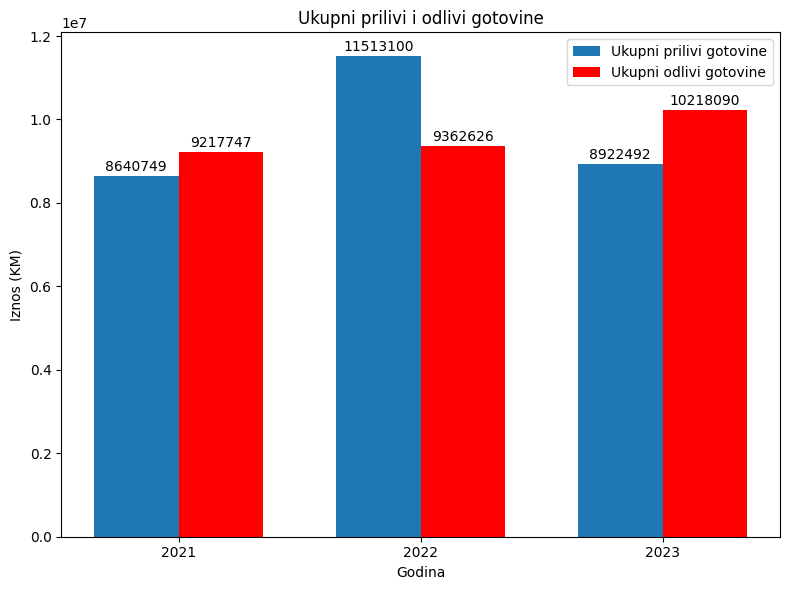

In [235]:
labels = ['2021', '2022', '2023']
priliv = [8640749.0, 11513100.0, 8922492.0]
odliv = [9217747, 9362626, 10218090]  

# Kreiranje bara
x = np.arange(len(labels))
width = 0.35  # Širina bara

# Kreiranje bar grafikona
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, priliv, width, label='Ukupni prilivi gotovine')
plt.bar(x + width/2, odliv, width, label='Ukupni odlivi gotovine', color='red')

# Dodavanje oznaka na osi i naslov
plt.xlabel('Godina')
plt.ylabel('Iznos (KM)')
plt.title('Ukupni prilivi i odlivi gotovine')
plt.xticks(x, labels)

# Dodavanje vrijednosti iznad bara
for i in range(len(labels)):
    plt.text(i - width/2, priliv[i] + 50000, f'{priliv[i]:.0f}', ha='center', va='bottom')
    plt.text(i + width/2, odliv[i] + 50000, f'{odliv[i]:.0f}', ha='center', va='bottom')

# Dodavanje legende
plt.legend()

# Prikaz grafikona
plt.tight_layout()
plt.show()

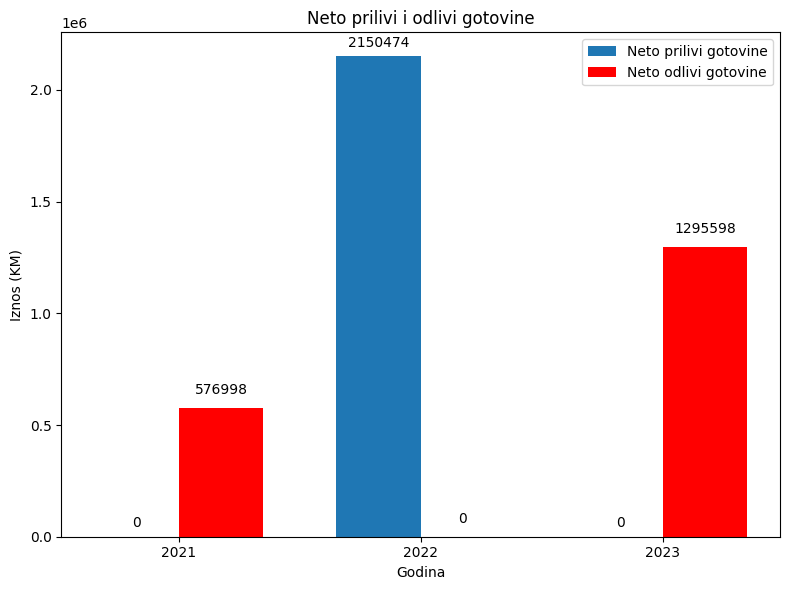

In [236]:
labels = ['2021', '2022', '2023']
priliv = [0, 2150474.0, 0]
odliv = [576998, 0, 1295598]  

# Kreiranje bara
x = np.arange(len(labels))
width = 0.35  # Širina bara

# Kreiranje bar grafikona
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, priliv, width, label='Neto prilivi gotovine')
plt.bar(x + width/2, odliv, width, label='Neto odlivi gotovine', color='red')

# Dodavanje oznaka na osi i naslov
plt.xlabel('Godina')
plt.ylabel('Iznos (KM)')
plt.title('Neto prilivi i odlivi gotovine')
plt.xticks(x, labels)

# Dodavanje vrijednosti iznad bara
for i in range(len(labels)):
    plt.text(i - width/2, priliv[i] + 30000, f'{priliv[i]:.0f}', ha='center', va='bottom')
    plt.text(i + width/2, odliv[i] + 50000, f'{odliv[i]:.0f}', ha='center', va='bottom')

# Dodavanje legende
plt.legend()

# Prikaz grafikona
plt.tight_layout()
plt.show()

In [ ]:
nt.tail(10)

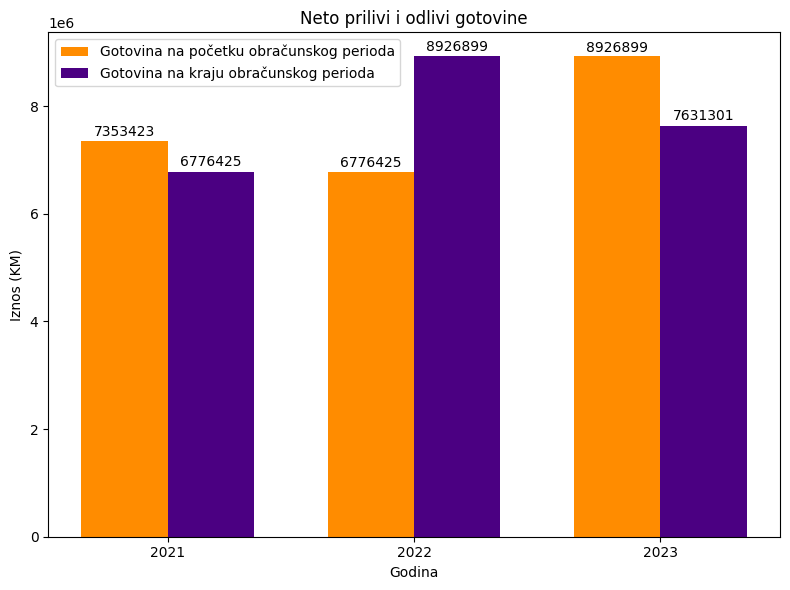

In [237]:
labels = ['2021', '2022', '2023']
gotovina_na_početku_perioda = [7353423, 6776425, 8926899]
gotovina_na_kraju_perioda = [6776425, 8926899, 7631301]  

# Kreiranje bara
x = np.arange(len(labels))
width = 0.35  # Širina bara

# Kreiranje bar grafikona
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, gotovina_na_početku_perioda, width, label='Gotovina na početku obračunskog perioda', color='darkorange')
plt.bar(x + width/2, gotovina_na_kraju_perioda, width, label='Gotovina na kraju obračunskog perioda', color='indigo')

# Dodavanje oznaka na osi i naslov
plt.xlabel('Godina')
plt.ylabel('Iznos (KM)')
plt.title('Neto prilivi i odlivi gotovine')
plt.xticks(x, labels)

# Dodavanje vrijednosti iznad bara
for i in range(len(labels)):
    plt.text(i - width/2, gotovina_na_početku_perioda[i] + 30000, f'{gotovina_na_početku_perioda[i]:.0f}', ha='center', va='bottom')
    plt.text(i + width/2, gotovina_na_kraju_perioda[i] + 50000, f'{gotovina_na_kraju_perioda[i]:.0f}', ha='center', va='bottom')

# Dodavanje legende
plt.legend()

# Prikaz grafikona
plt.tight_layout()
plt.show()